# Imports

In [13]:
# Plotting
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Math + stats
import numpy as np
import pandas as pd
from scipy.stats import binom
from scipy.stats import t
import scipy.stats as stats

# Logistics
from os.path import sep
from tqdm import tqdm
import sys
import time

# Local modules
sys.path.append('/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation')
import edu_nested_simulation_functions
import ecd_nested_simulation_functions.generate_ecd_dummy_data as generate_ecd_dummy_data
import ecd_nested_simulation_functions.ecd_sampling_strategy as ecd_sampling_strategy
from AS_extract_data_from_dta_file import extract_data_from_dta

# Enable re-load of local modules every time they are called
%load_ext autoreload
%autoreload 2
%aimport numpy 
%aimport pandas

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Education

## Parameters

In [ ]:
# Structural parameters
students_per_school = 20  # Number of students in a school (> 0)
n_schools_per_L1 = 20 # Number of schools in each L1 unit (> 0)
n_L1s_per_L2 = 10 # Number of L1s in each L2 unit (L2 visits all L1s) (> 0)
n_L2s = 1 # Number of L2s (> 0)
L1_retest_percentage = 100 # Percentage of students in a school retested by L1 (between 0 to 100)
L2_retest_percentage_schools = 50 # Percentage of schools visited by L2 in a given L1 unit (between 0 to 100)
L2_retest_percentage_students = 50 # Percentage of students retested by L2 (from eligible students, i.e. 
                                        # those retested by L1) (between 0 to 100)

# Subjects parameters - mean and standard deviation of scores, and granularity, i.e. the number of possible 
                                            # unique scores for a student
# Mean should be between 0 - 100
# Standard deviation can be any number > 0, larger value will give more spread across students
# Granularity should be between 2 (binary - pass/fail) and 101 (marks as percentage)
subjects = ['Maths', 'English', 'Tamil']
subjects_params = {
    "Maths": {"mean": 55, "std_dev": 30, "granularity": 101},
    "English": {"mean": 70, "std_dev": 20, "granularity": 101},
    "Tamil": {"mean": 60, "std_dev": 20, "granularity": 101}
}
passing_marks = {"Maths": 80, "English": 90, "Tamil": 90}  # Passing marks for each subject (between 0 and 100)

# Distortion parameters (common)
measurement_error_mean = 0 # Keep at 0 since we are assuming measurement error centered around zero
                           # But technically can be any positive or negative number.
measurement_error_std_dev = 10 # Any number > 0. Larger will give more noise

# L0 distortion parameters
minimum_marks_mean = {'Maths': 50, 'English': 60, 'Tamil': 60} # Between 0 and passing marks for the subject.
                                                          # Higher --> more integrity distortion
minimum_marks_std_dev = {'Maths': 10, 'English': 10, 'Tamil': 10}
delta_mean = 5 # Marks below passing mark at which L0 starts giving passing marks (between 0 and passing marks)
delta_std_dev = 1

# L1 distortion parameters
collusion_index = 0.2  # Collusion index for L1 distortion - between 0 and 1. 0 means no L1 integrity distortion;
                       # 1 means L1 integrity distortion is as much as L0. 
moderation_index_L1 = 0 # Moderation for L1 distortion - between -100 and 100

# L2 distortion parameters
moderation_index_L2 = 0  # Moderation index for L2 distortion - between -100 and 100

## Real scores

Text(0, 0.5, 'Number of students')

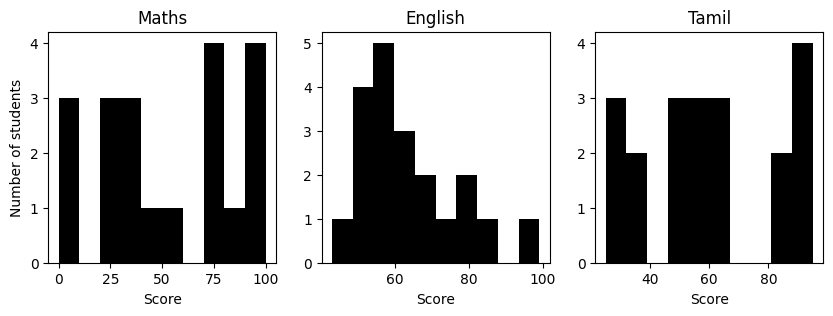

In [ ]:
subjects = list(subjects_params.keys())
n_subjects = len(subjects)    

# Generate real scores
real_scores = edu_nested_simulation_functions.generate_real_scores(students_per_school, subjects_params)

fig, ax = plt.subplots(nrows = 1, ncols = n_subjects, figsize = [10, 3])
for i in range(n_subjects):
    ax[i].hist(real_scores[subjects[i]], color = 'k')
    ax[i].set_xlabel('Score')
    ax[i].set_title(subjects[i])
    
ax[0].set_ylabel('Number of students')

## L0 scores (single school)

Minimum marks: {'Maths': 45.156243080306965, 'English': 76.38859986373953, 'Tamil': 62.252353528056034}
Delta = 5.166429535803161


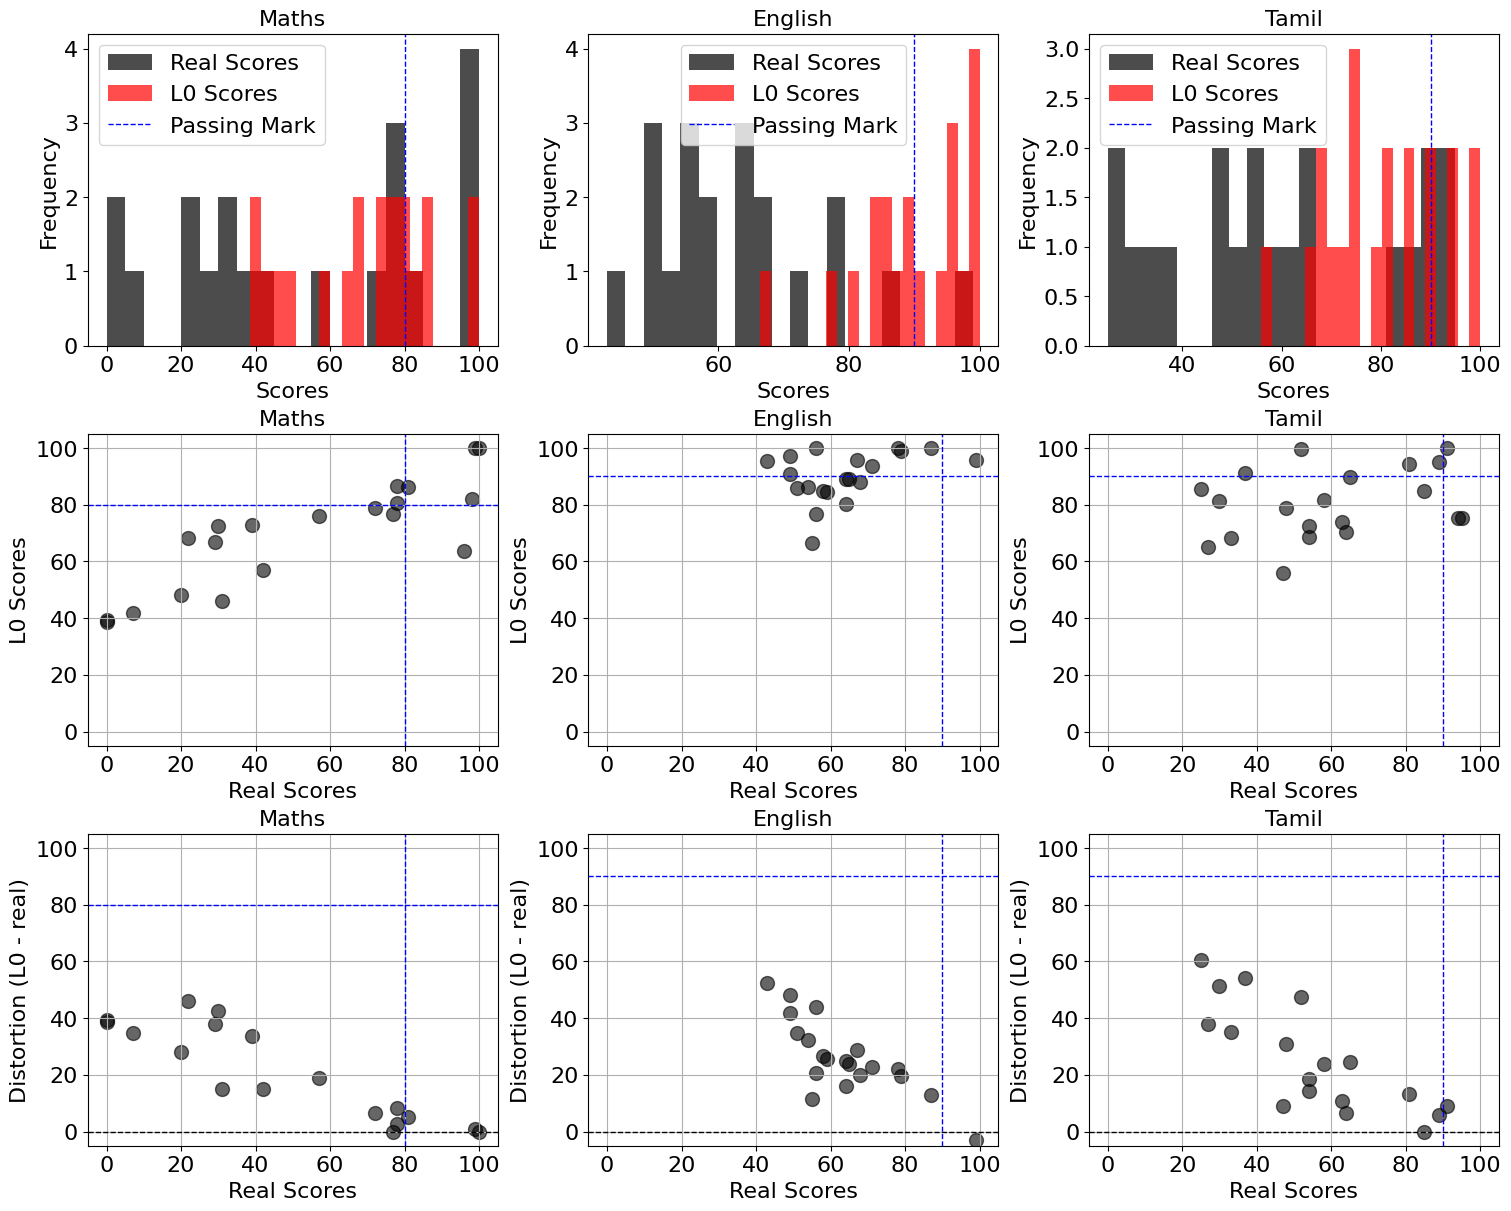

In [ ]:
# Apply L0 distortions
minimum_marks = {
                    subject: np.random.normal(loc=minimum_marks_mean[subject], scale=minimum_marks_std_dev[subject])
                    for subject in subjects_params.keys()
                }
delta = np.random.normal(loc=delta_mean, scale=delta_std_dev)

print('Minimum marks: {0}'.format(minimum_marks))
print('Delta = {0}'.format(delta))

L0_scores = edu_nested_simulation_functions.apply_distortion_L0(real_scores, passing_marks, 
                                                            minimum_marks,
                                                            delta,
                                                       measurement_error_mean = measurement_error_mean,
                                                    measurement_error_std_dev = measurement_error_std_dev)

# General plot settings
font_size = 16  # Font size for titles, labels, and ticks
scatter_point_size = 100  # Size of points in scatter plots
hist_color_real = "black"  # Color for real scores in histograms
hist_color_L0 = "red"  # Color for L0 scores in histograms
scatter_color = "black"  # Color for scatter plots
pass_mark_color = "blue" # Color for dashed vertical line indicating passing marks
axis_limits = [-5, 105]

# Create subplots for histograms
fig, axes = plt.subplots(3, len(subjects_params), figsize=(15, 12), constrained_layout=True)

# Plot histograms for real scores and L0 scores for each subject
for idx, subject in enumerate(subjects_params.keys()):
    
    passing_mark = passing_marks[subject]

    # Histogram for real scores
    axes[0, idx].hist(real_scores[subject], bins=20, alpha=0.7, label="Real Scores", color=hist_color_real)
    axes[0, idx].hist(L0_scores[subject], bins=20, alpha=0.7, label="L0 Scores", color=hist_color_L0)
    axes[0, idx].axvline(passing_mark, color = pass_mark_color, linestyle="--", linewidth=1, label="Passing Mark")
    axes[0, idx].set_title(subject, fontsize=font_size)
    axes[0, idx].set_xlabel("Scores", fontsize=font_size)
    axes[0, idx].set_ylabel("Frequency", fontsize=font_size)
    axes[0, idx].tick_params(axis="both", labelsize=font_size)
    axes[0, idx].legend(fontsize=font_size)

    # Scatter plot: L0 scores vs Real scores
    axes[1, idx].scatter(real_scores[subject], L0_scores[subject], alpha=0.6, color=scatter_color, s=scatter_point_size)
    axes[1, idx].axvline(passing_mark, color="blue", linestyle="--", linewidth=1, label="Passing Mark")
    axes[1, idx].axhline(passing_mark, color="blue", linestyle="--", linewidth=1)
    axes[1, idx].set_title(subject, fontsize=font_size)
    axes[1, idx].set_xlabel("Real Scores", fontsize=font_size)
    axes[1, idx].set_ylabel("L0 Scores", fontsize=font_size)
    axes[1, idx].tick_params(axis="both", labelsize=font_size)
    axes[1, idx].set_xlim(axis_limits)
    axes[1, idx].set_ylim(axis_limits)
    axes[1, idx].grid(True)

    distortion = L0_scores[subject] - real_scores[subject]
    axes[2, idx].scatter(real_scores[subject], distortion, alpha=0.6, color=scatter_color, s=scatter_point_size)
    axes[2, idx].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[2, idx].axvline(passing_mark, color="blue", linestyle="--", linewidth=1, label="Passing Mark")
    axes[2, idx].axhline(passing_mark, color="blue", linestyle="--", linewidth=1)
    axes[2, idx].set_title(subject, fontsize=font_size)
    axes[2, idx].set_xlabel("Real Scores", fontsize=font_size)
    axes[2, idx].set_ylabel("Distortion (L0 - real)", fontsize=font_size)
    axes[2, idx].tick_params(axis="both", labelsize=font_size)
    axes[2, idx].set_xlim(axis_limits)
    axes[2, idx].set_ylim(axis_limits)
    axes[2, idx].grid(True)

plt.show()

## L1 scores (single school, all students)

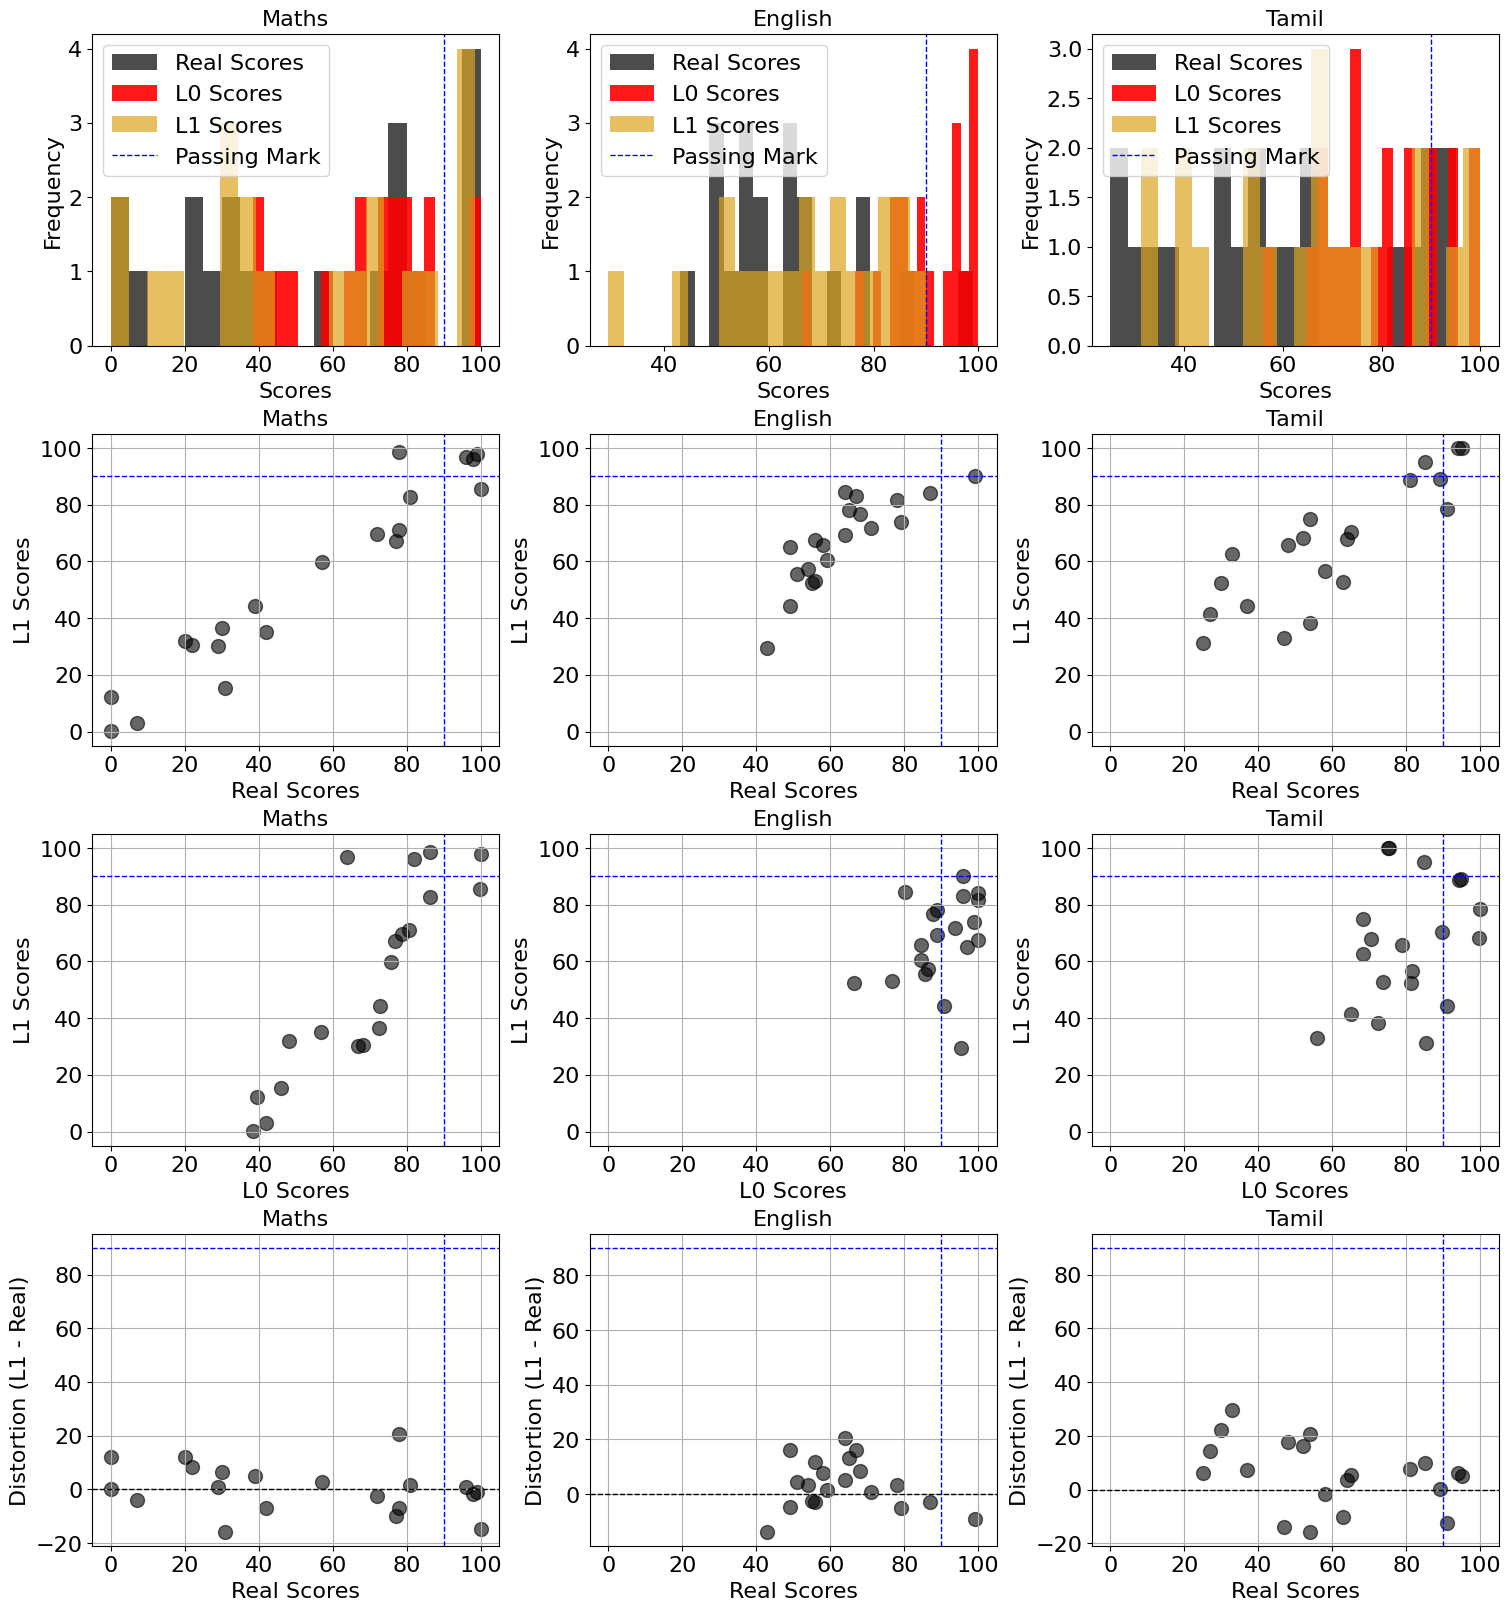

In [ ]:
# Apply L1 distortions
L1_scores = edu_nested_simulation_functions.apply_distortion_L1(real_scores, passing_marks, minimum_marks,
                                                            delta, collusion_index,
                                                            measurement_error_mean = measurement_error_mean, 
                                                        measurement_error_std_dev = measurement_error_std_dev,
                                                           moderation_index_L1 = moderation_index_L1)

# General plot settings
font_size = 16  # Font size for titles, labels, and ticks
scatter_point_size = 100  # Size of points in scatter plots
hist_color_real = "black"  # Color for real scores in histograms
hist_color_L0 = "red"  # Color for L0 scores in histograms
hist_color_L1 = "goldenrod"  # Color for L1 scores in histograms
scatter_color = "black"  # Color for scatter plots
pass_mark_color = "blue" # Color for dashed line indicating passing mark
axis_limits = [-5, 105]  # Axis limits for scatter plots

# Create subplots for histograms
fig, axes = plt.subplots(4, len(subjects_params), figsize=(15, 16), constrained_layout=True)

# Plot histograms for real scores, L0 scores, and L1 scores for each subject
for idx, subject in enumerate(subjects_params.keys()):
    # Histogram for real scores
    axes[0, idx].hist(real_scores[subject], bins=20, alpha=0.7, label="Real Scores", color=hist_color_real)
    axes[0, idx].hist(L0_scores[subject], bins=20, alpha=0.9, label="L0 Scores", color=hist_color_L0)
    axes[0, idx].hist(L1_scores[subject], bins=20, alpha=0.7, label="L1 Scores", color=hist_color_L1)
    axes[0, idx].axvline(passing_mark, color = pass_mark_color, linestyle="--", linewidth=1, label="Passing Mark")
    axes[0, idx].set_title(subject, fontsize=font_size)
    axes[0, idx].set_xlabel("Scores", fontsize=font_size)
    axes[0, idx].set_ylabel("Frequency", fontsize=font_size)
    axes[0, idx].tick_params(axis="both", labelsize=font_size)
    axes[0, idx].legend(fontsize=font_size)

    # Scatter plot: L1 scores vs Real scores
    axes[1, idx].scatter(real_scores[subject], L1_scores[subject], alpha=0.6, color=scatter_color, s=scatter_point_size)
    axes[1, idx].axvline(passing_mark, color="blue", linestyle="--", linewidth=1, label="Passing Mark")
    axes[1, idx].axhline(passing_mark, color="blue", linestyle="--", linewidth=1)
    axes[1, idx].set_title(subject, fontsize=font_size)
    axes[1, idx].set_xlabel("Real Scores", fontsize=font_size)
    axes[1, idx].set_ylabel("L1 Scores", fontsize=font_size)
    axes[1, idx].tick_params(axis="both", labelsize=font_size)
    axes[1, idx].grid(True)
    axes[1, idx].set_xlim(axis_limits)
    axes[1, idx].set_ylim(axis_limits)

    # Scatter plot: L1 scores vs L0 scores
    axes[2, idx].scatter(L0_scores[subject], L1_scores[subject], alpha=0.6, color=scatter_color, s=scatter_point_size)
    axes[2, idx].axvline(passing_mark, color="blue", linestyle="--", linewidth=1, label="Passing Mark")
    axes[2, idx].axhline(passing_mark, color="blue", linestyle="--", linewidth=1)
    axes[2, idx].set_title(subject, fontsize=font_size)
    axes[2, idx].set_xlabel("L0 Scores", fontsize=font_size)
    axes[2, idx].set_ylabel("L1 Scores", fontsize=font_size)
    axes[2, idx].tick_params(axis="both", labelsize=font_size)
    axes[2, idx].grid(True)
    axes[2, idx].set_xlim(axis_limits)
    axes[2, idx].set_ylim(axis_limits)

    # Plot distortion (L1 score - Real score) vs Real scores for each subject
    distortion = L1_scores[subject] - real_scores[subject]
    axes[3, idx].scatter(real_scores[subject], distortion, alpha=0.6, color=scatter_color, s=scatter_point_size)
    axes[3, idx].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[3, idx].axvline(passing_mark, color="blue", linestyle="--", linewidth=1, label="Passing Mark")
    axes[3, idx].axhline(passing_mark, color="blue", linestyle="--", linewidth=1)
    axes[3, idx].set_title(subject, fontsize=font_size)
    axes[3, idx].set_xlabel("Real Scores", fontsize=font_size)
    axes[3, idx].set_ylabel("Distortion (L1 - Real)", fontsize=font_size)
    axes[3, idx].tick_params(axis="both", labelsize=font_size)
    axes[3, idx].grid(True)
    axes[3, idx].set_xlim(axis_limits)

plt.show()

## L2 scores (single school, all students)

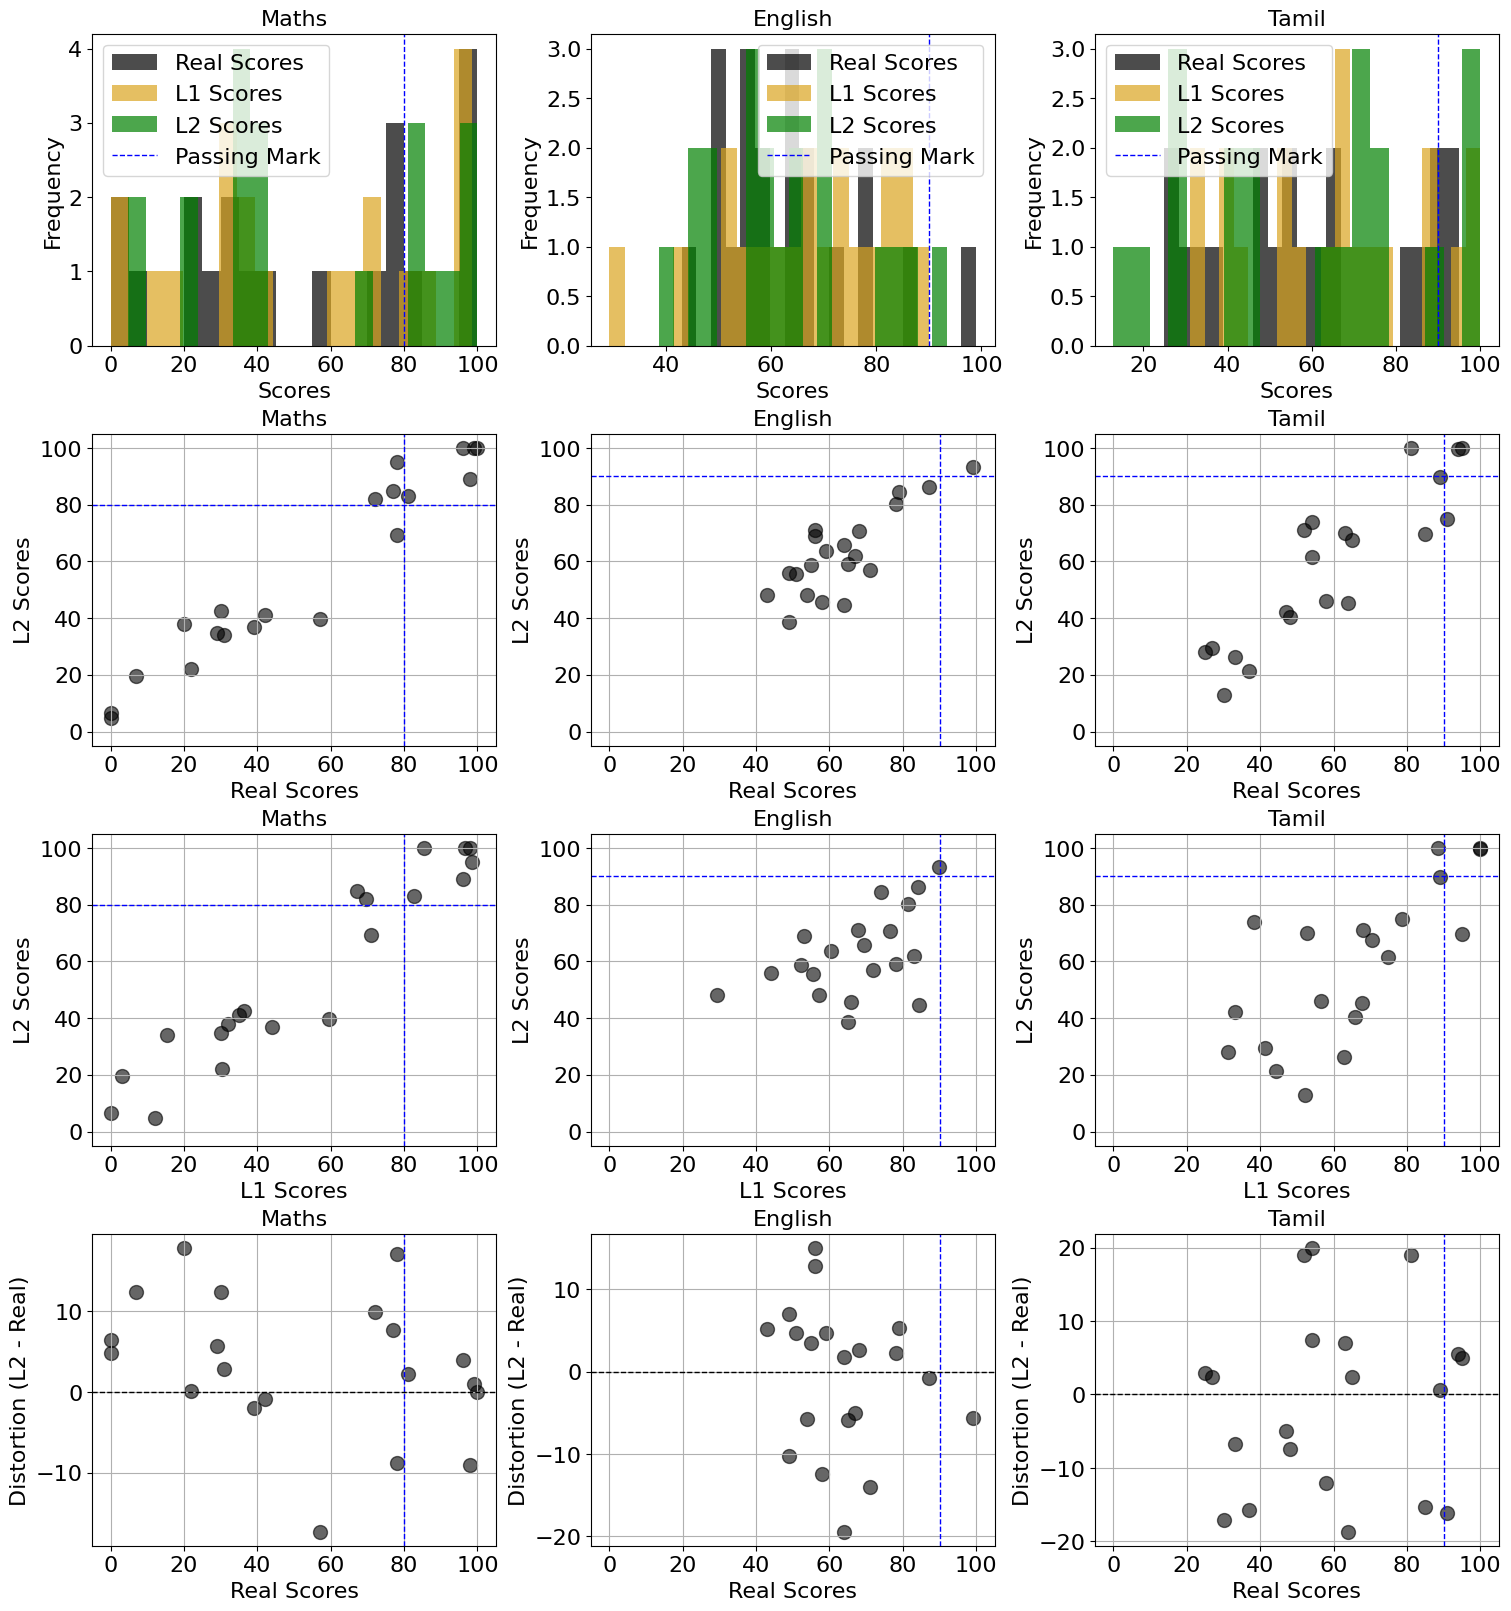

In [112]:
# Apply L2 distortions
L2_scores = edu_nested_simulation_functions.apply_distortion_L2(real_scores, 
                                                            measurement_error_mean = measurement_error_mean, 
                                                            measurement_error_std_dev = measurement_error_std_dev, 
                                                            moderation_index_L2 = moderation_index_L2)

# General plot settings
font_size = 16  # Font size for titles, labels, and ticks
scatter_point_size = 100  # Size of points in scatter plots
hist_color_real = "black"  # Color for real scores in histograms
hist_color_L1 = "goldenrod"  # Color for L1 scores in histograms
hist_color_L2 = "green"  # Color for L2 scores in histograms
scatter_color = "black"  # Color for scatter plots
axis_limits = [-5, 105]  # Axis limits for scatter plots

# Create subplots for histograms
fig, axes = plt.subplots(4, len(subjects_params), figsize=(15, 16), constrained_layout=True)

# Plot histograms for real scores, L1 scores, and L2 scores for each subject
for idx, subject in enumerate(subjects_params.keys()):
    passing_mark = passing_marks[subject]

    # Histogram for real scores
    axes[0, idx].hist(real_scores[subject], bins=20, alpha=0.7, label="Real Scores", color=hist_color_real)
    axes[0, idx].hist(L1_scores[subject], bins=20, alpha=0.7, label="L1 Scores", color=hist_color_L1)
    axes[0, idx].hist(L2_scores[subject], bins=20, alpha=0.7, label="L2 Scores", color=hist_color_L2)
    axes[0, idx].axvline(passing_mark, color="blue", linestyle="--", linewidth=1, label="Passing Mark")
    axes[0, idx].set_title(subject, fontsize=font_size)
    axes[0, idx].set_xlabel("Scores", fontsize=font_size)
    axes[0, idx].set_ylabel("Frequency", fontsize=font_size)
    axes[0, idx].tick_params(axis="both", labelsize=font_size)
    axes[0, idx].legend(fontsize=font_size)

    # Scatter plot: L2 scores vs Real scores
    axes[1, idx].scatter(real_scores[subject], L2_scores[subject], alpha=0.6, color=scatter_color, s=scatter_point_size)
    axes[1, idx].axvline(passing_mark, color="blue", linestyle="--", linewidth=1, label="Passing Mark")
    axes[1, idx].axhline(passing_mark, color="blue", linestyle="--", linewidth=1)
    axes[1, idx].set_title(subject, fontsize=font_size)
    axes[1, idx].set_xlabel("Real Scores", fontsize=font_size)
    axes[1, idx].set_ylabel("L2 Scores", fontsize=font_size)
    axes[1, idx].tick_params(axis="both", labelsize=font_size)
    axes[1, idx].grid(True)
    axes[1, idx].set_xlim(axis_limits)
    axes[1, idx].set_ylim(axis_limits)

    # Scatter plot: L2 scores vs L1 scores
    axes[2, idx].scatter(L1_scores[subject], L2_scores[subject], alpha=0.6, color=scatter_color, s=scatter_point_size)
    axes[2, idx].axvline(passing_mark, color="blue", linestyle="--", linewidth=1, label="Passing Mark")
    axes[2, idx].axhline(passing_mark, color="blue", linestyle="--", linewidth=1)
    axes[2, idx].set_title(subject, fontsize=font_size)
    axes[2, idx].set_xlabel("L1 Scores", fontsize=font_size)
    axes[2, idx].set_ylabel("L2 Scores", fontsize=font_size)
    axes[2, idx].tick_params(axis="both", labelsize=font_size)
    axes[2, idx].grid(True)
    axes[2, idx].set_xlim(axis_limits)
    axes[2, idx].set_ylim(axis_limits)

    # Plot distortion (L2 score - Real score) vs Real scores for each subject
    passing_mark = passing_marks[subject]
    distortion = L2_scores[subject] - real_scores[subject]
    axes[3, idx].scatter(real_scores[subject], distortion, alpha=0.6, color=scatter_color, s=scatter_point_size)
    axes[3, idx].axvline(passing_mark, color="blue", linestyle="--", linewidth=1, label="Passing Mark")
    axes[3, idx].axhline(0, color="black", linestyle="--", linewidth=1)
    axes[3, idx].set_title(subject, fontsize=font_size)
    axes[3, idx].set_xlabel("Real Scores", fontsize=font_size)
    axes[3, idx].set_ylabel("Distortion (L2 - Real)", fontsize=font_size)
    axes[3, idx].tick_params(axis="both", labelsize=font_size)
    axes[3, idx].grid(True)
    axes[3, idx].set_xlim(axis_limits)

plt.show()

## Simulate nested scores

Structure of the generated dictionary nested_scores is as follows:

L2 ID -> L1 ID -> School ID (equivalent to L0 ID) -> 

        -> real scores -> student ID -> subject
        -> L0 scores -> student ID -> subject
        -> L1 scores -> student ID [may not exist for all students] -> subject
        -> L2 scores [may not exist for all schools] -> student ID [may not exist for all students] -> subject

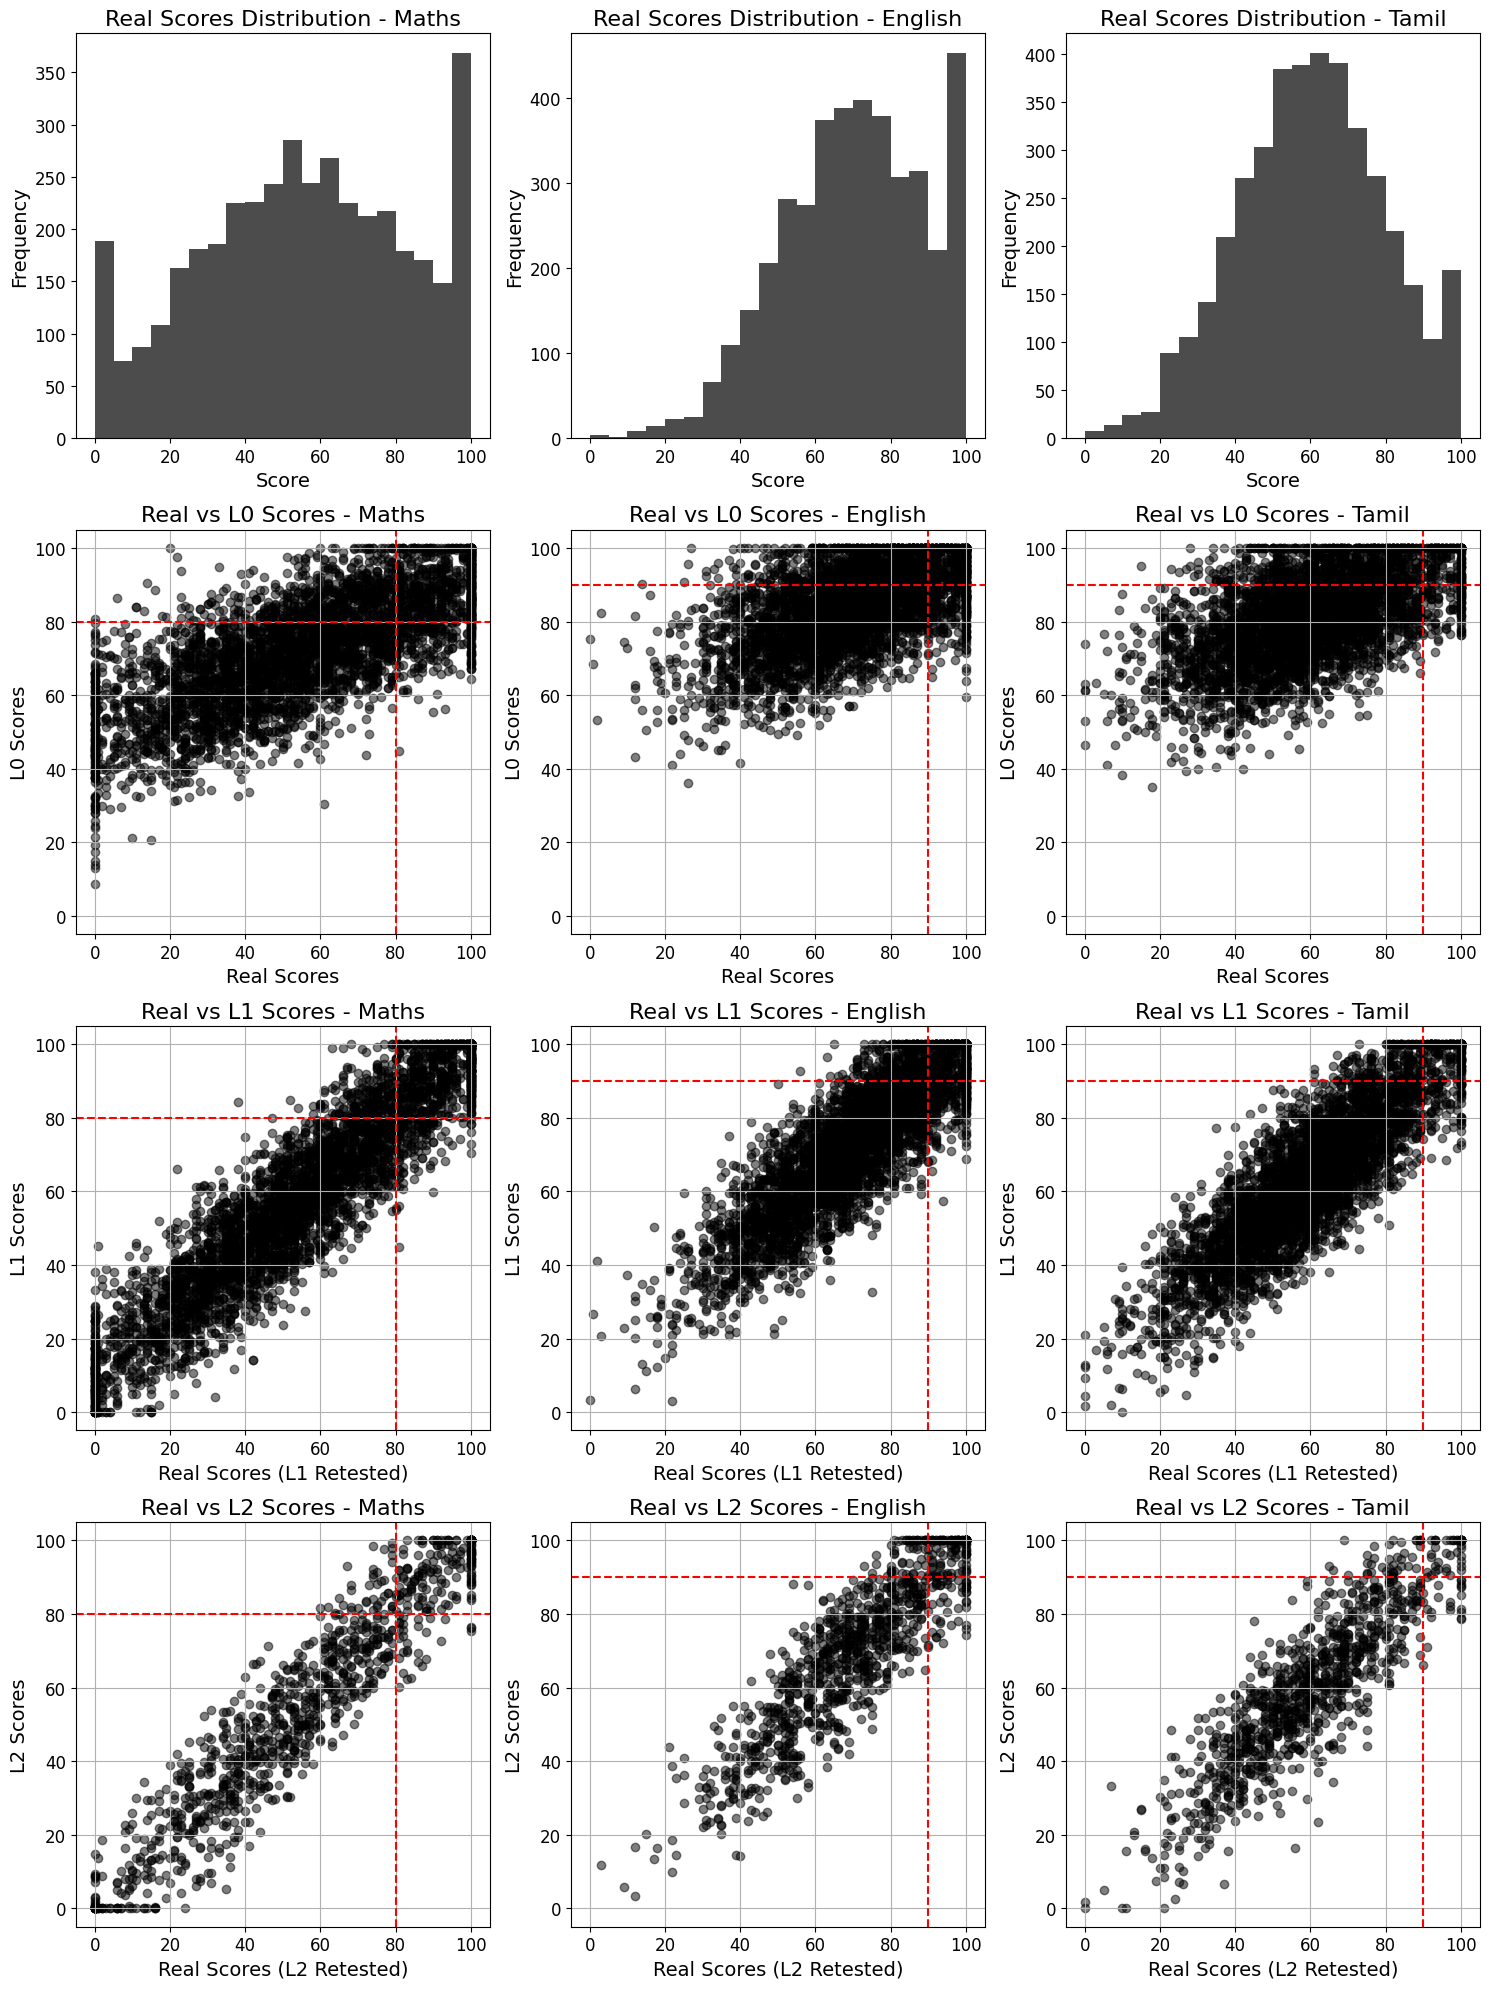

In [113]:
nested_scores = edu_nested_simulation_functions.simulate_test_scores(
    students_per_school, 
    subjects_params, 
    passing_marks, 
    minimum_marks_mean,
    minimum_marks_std_dev,
    delta_mean,
    delta_std_dev,
    n_schools_per_L1, 
    n_L1s_per_L2, 
    n_L2s, 
    L1_retest_percentage, 
    L2_retest_percentage_schools, 
    L2_retest_percentage_students, 
    collusion_index, 
    moderation_index_L1 = moderation_index_L1, 
    moderation_index_L2 = moderation_index_L2, 
    measurement_error_mean = measurement_error_mean, 
    measurement_error_std_dev = measurement_error_std_dev,
)

edu_nested_simulation_functions.plot_nested_scores(nested_scores, subjects, passing_marks)

## Discrepancy scores

### Non-binary (using all information)

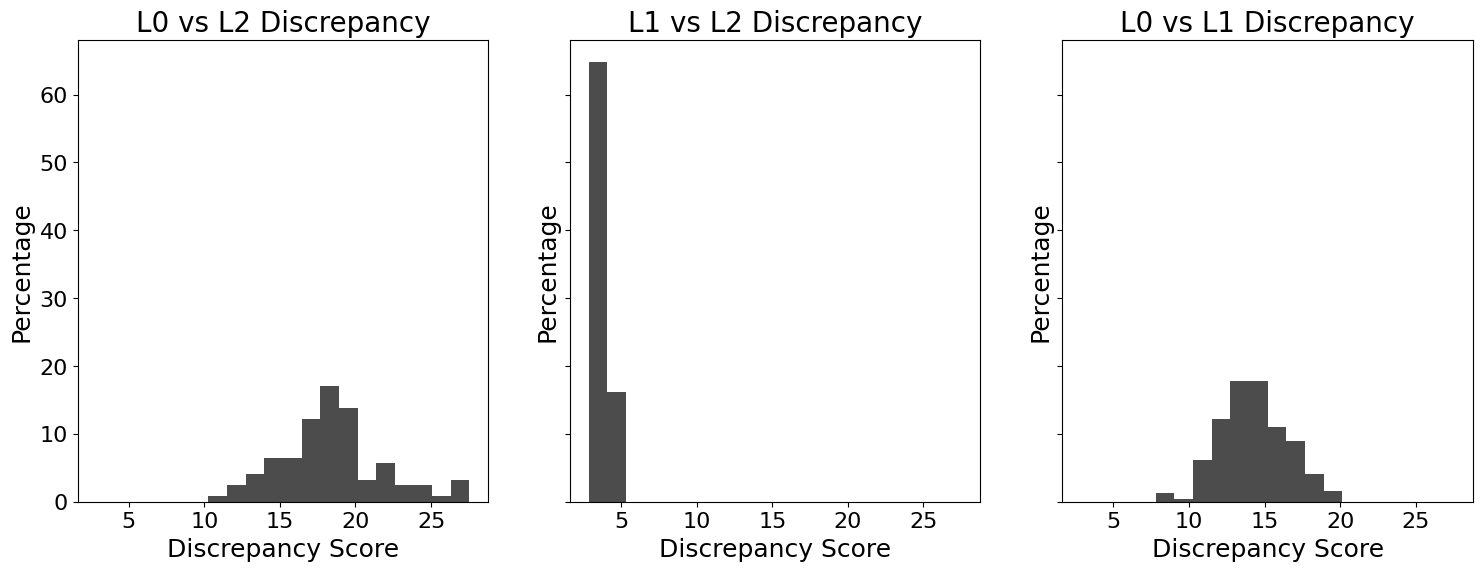

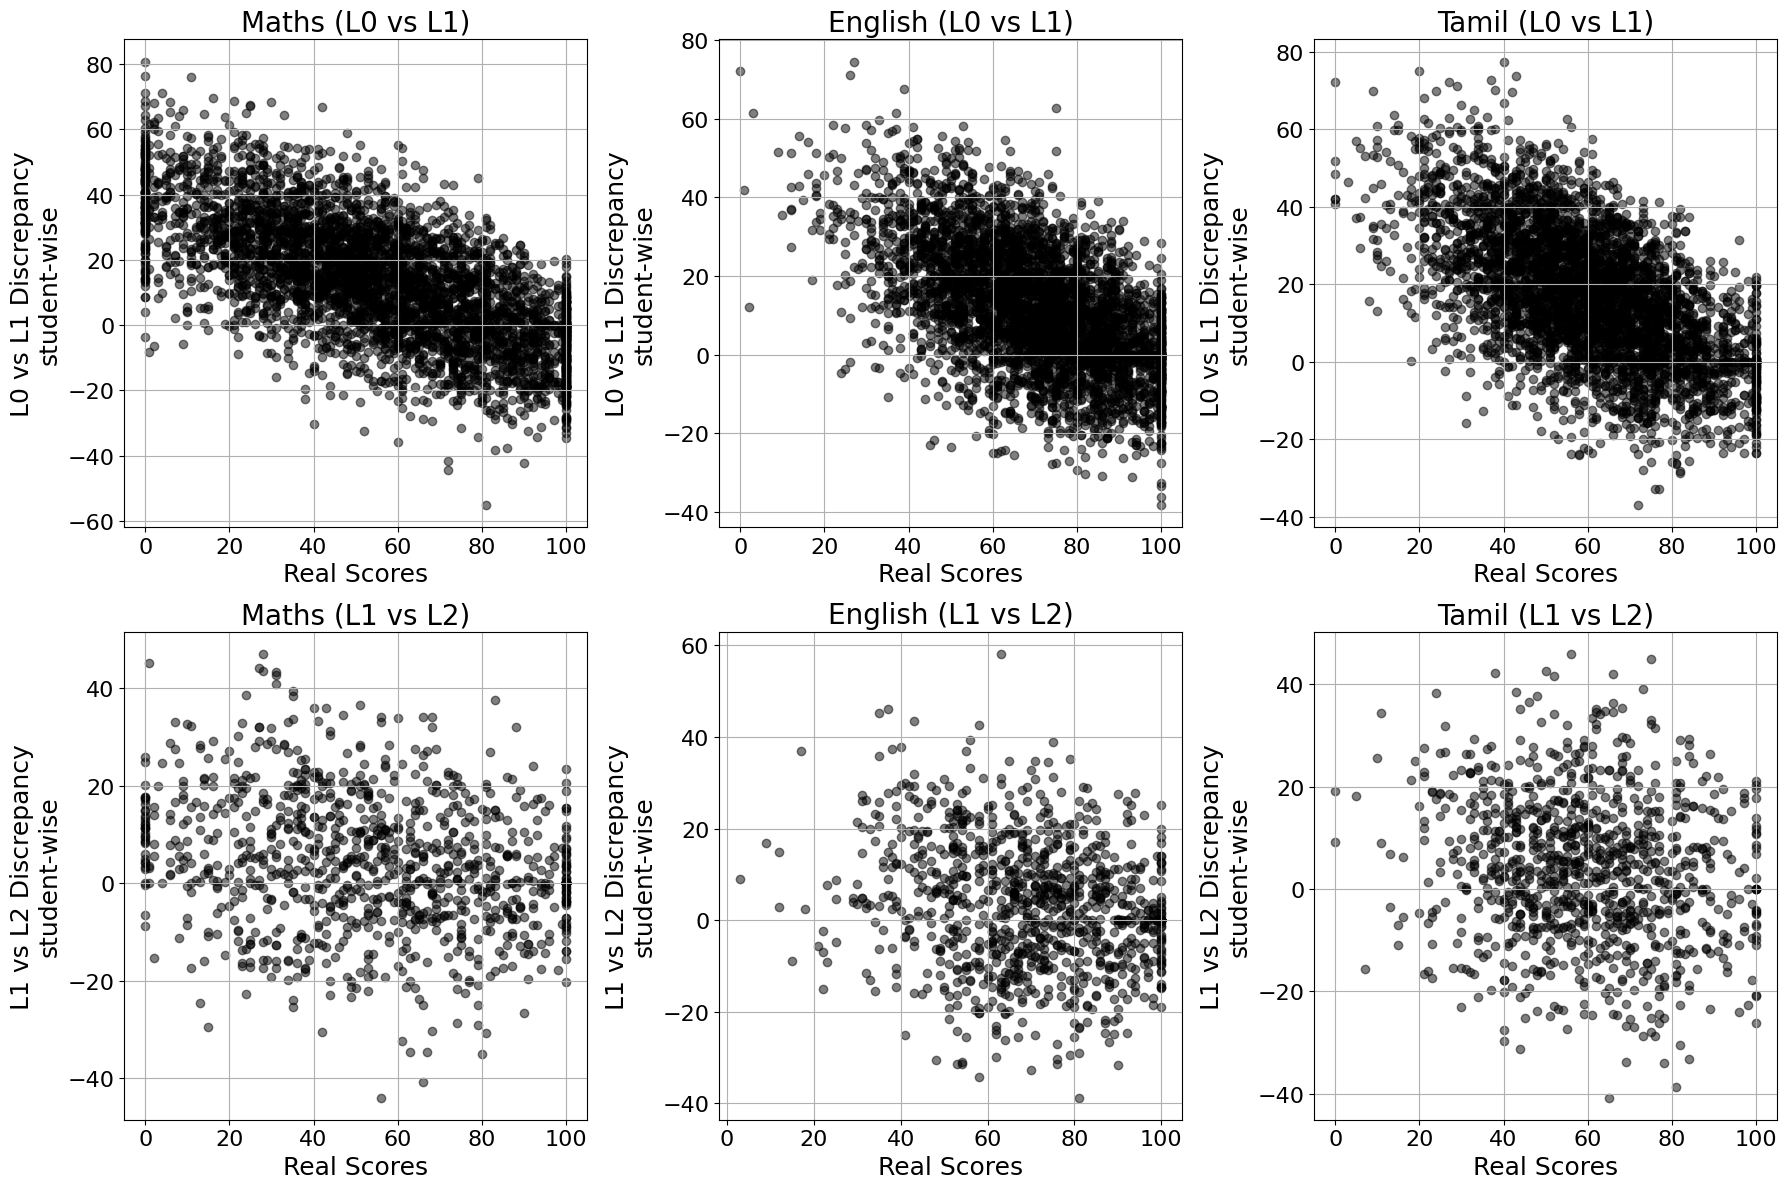

In [114]:
# Note: Type of discrepancy calculation (second parameter) can be: 
# 'simple_difference', 
# 'percent_difference', 
# 'absolute_difference', 
# 'absolute_percent_difference', 
# 'percent_non_match' (binary),
# 'directional_percent_non_match' (binary and only counts discrepancy when subordinate fails and supervisor passes),
# 'directional_difference' (only counts discrepancy when subordinate marks are higher than supervisor)

results = edu_nested_simulation_functions.calculate_disc_scores(nested_scores, # Generated in cell 7
                                                            'simple_difference', # discrepancy calculation method - see note
                                                           passing_marks, # Defined in cell 2
                                                            subjects,
                                                           ) 

### Binary (pass-fail mismatch)

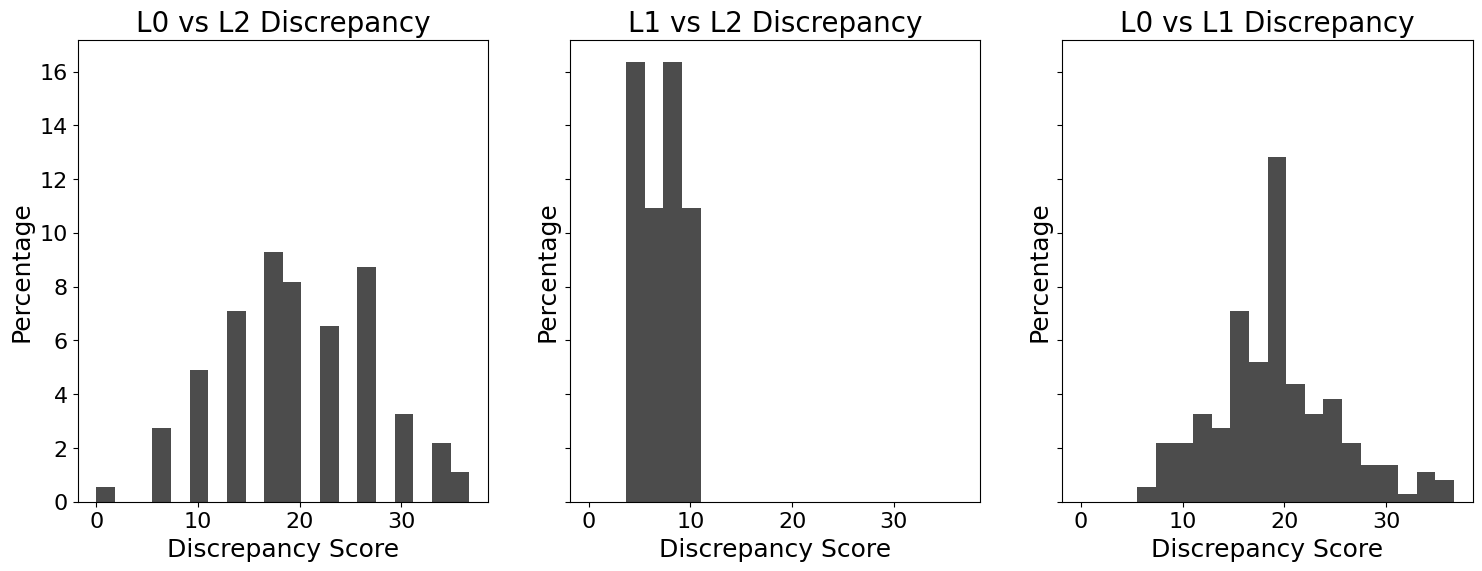

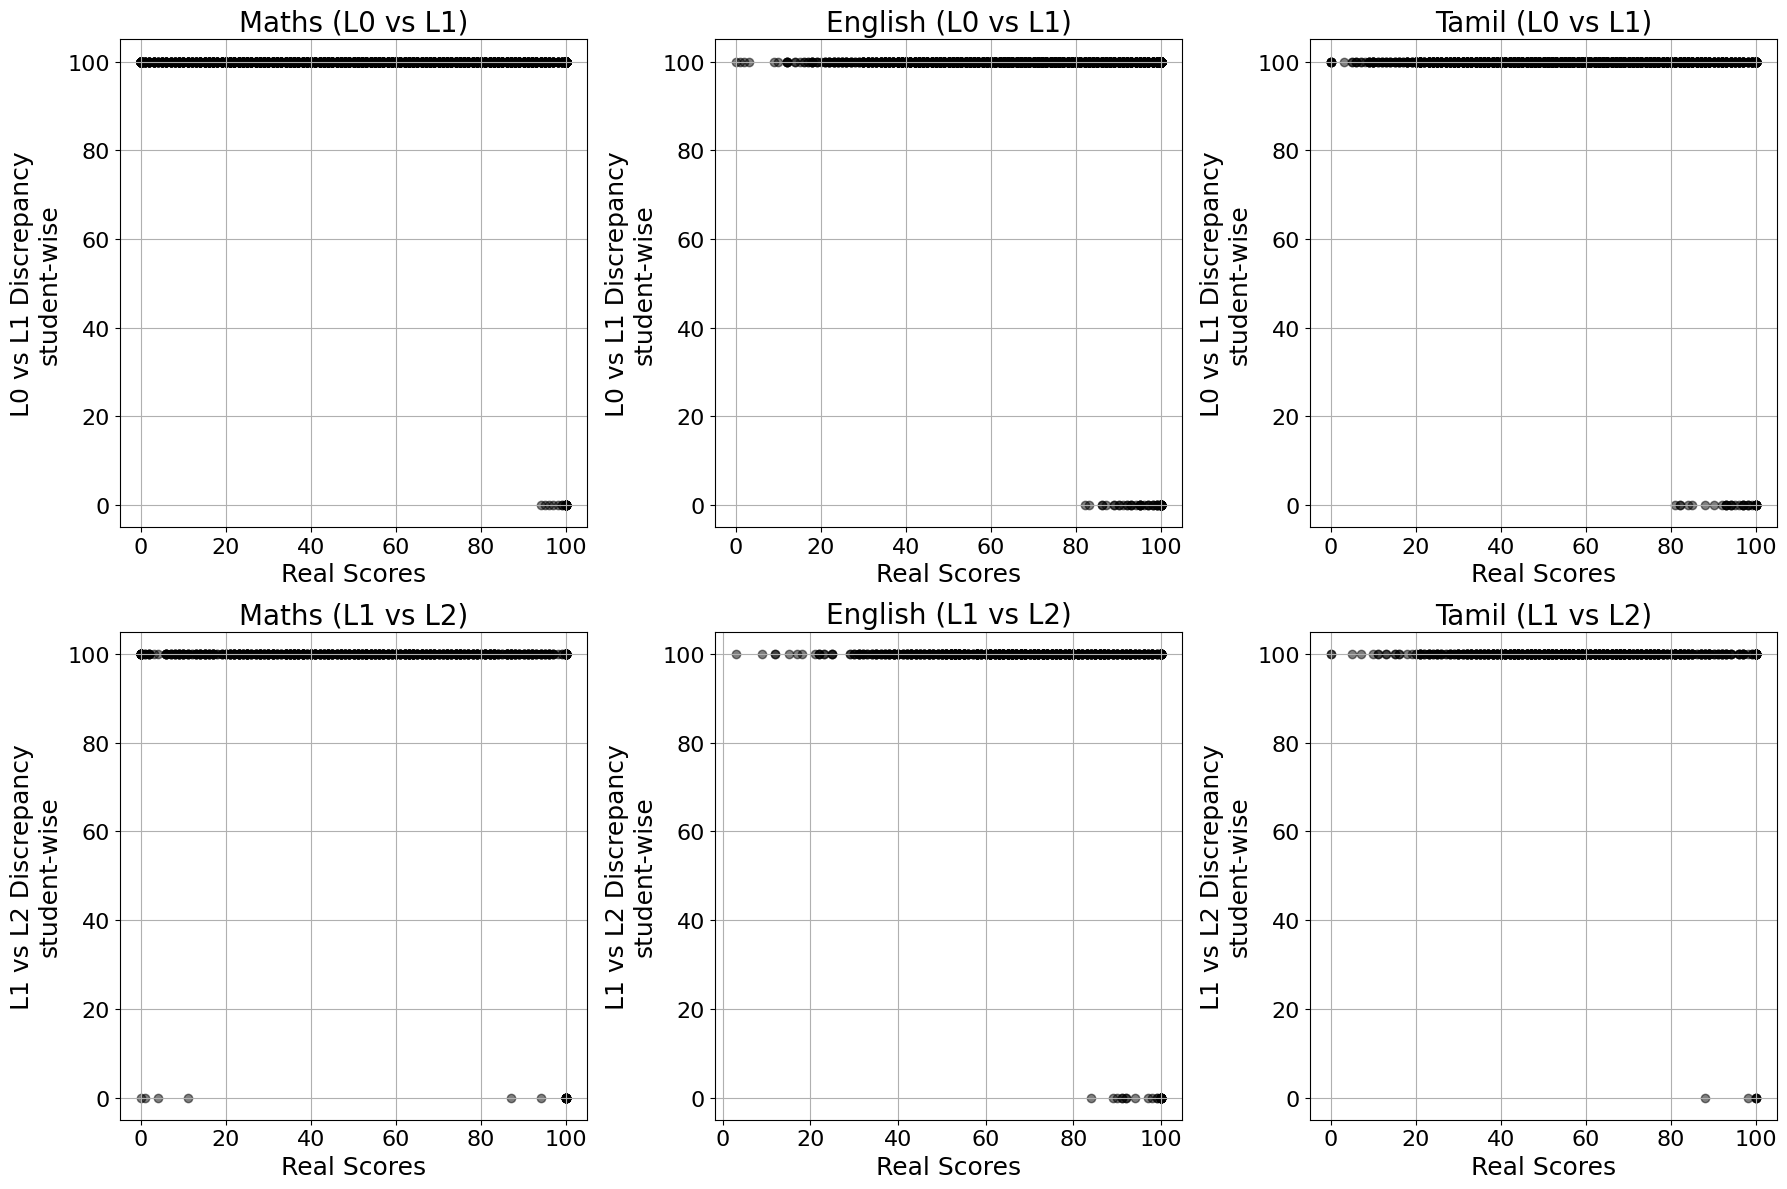

In [115]:
results = edu_nested_simulation_functions.calculate_disc_scores(nested_scores, 'directional_percent_non_match',
                                                           passing_marks, subjects)

## Confidence guarantees

### Number of 'real' L0s in green zone, for a single L1

Structure of the generated dictionary nested_scores is as follows:

L2 ID -> L1 ID -> School ID (equivalent to L0 ID) -> 

        -> real scores -> student ID -> subject
        -> L0 scores -> student ID -> subject
        -> L1 scores -> student ID [may not exist for all students] -> subject
        -> L2 scores [may not exist for all schools] -> student ID [may not exist for all students] -> subject

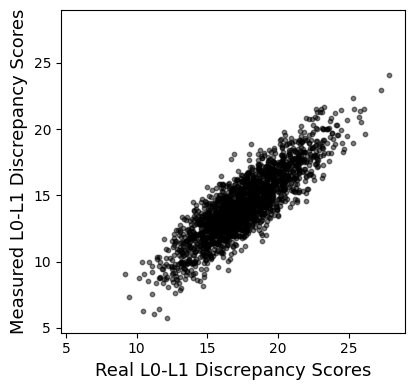

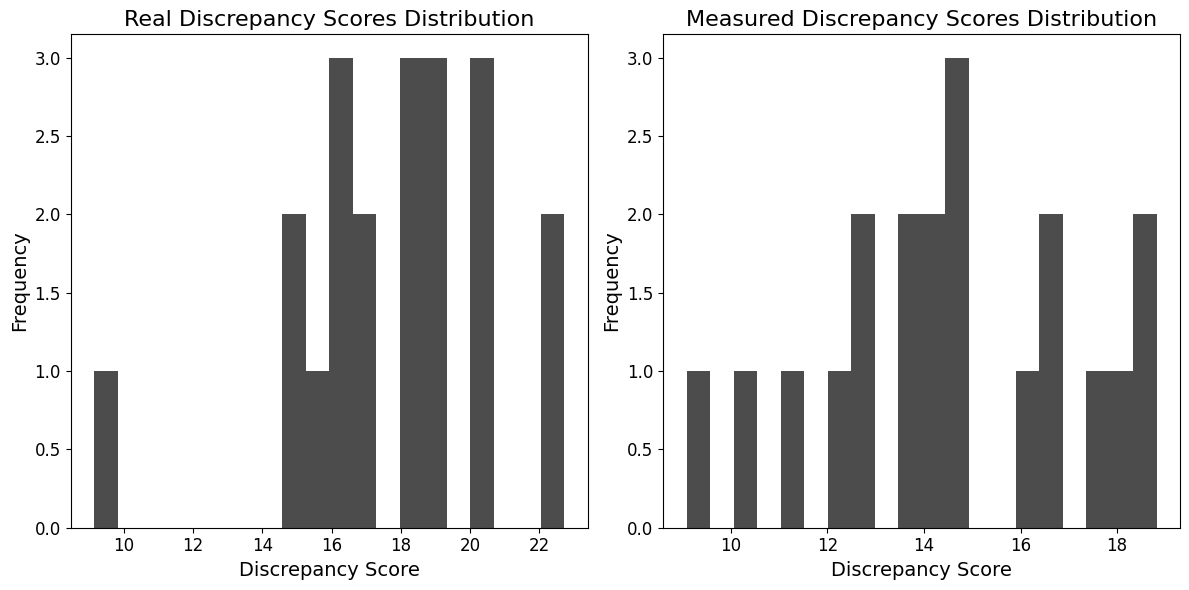

Number of true L0s = 3.64 out of 5
CIs = 3.4920514303248216, 3.7879485696751787
L2-L1 truth scores = [np.float64(3.0304289461453253), np.float64(4.309575413523163), np.float64(2.9274103986159483), np.float64(2.8023311445247003), np.float64(4.088245096855409), np.float64(3.626164736030222), np.float64(3.132779155028748), np.float64(4.44812474659619), np.float64(3.13140378828948), np.float64(3.1150776225574943), np.float64(2.4038905283066527), np.float64(2.2736652077671398), np.float64(3.293065580730835), np.float64(2.820464565704853), np.float64(2.716025491404302), np.float64(5.323179742507101), np.float64(1.682932194846196), np.float64(2.5124288542601443), np.float64(3.2698502956519957), np.float64(2.6389789969080235), np.float64(2.4799843800732173), np.float64(3.765420374356241), np.float64(3.990146325721621), np.float64(3.1340502046758063), np.float64(4.233100027703172), np.float64(2.3700597320285524), np.float64(4.099978717110232), np.float64(3.1557400434936302), np.float64(4.426311

In [116]:
n_simulations = 100
method = 'simple_difference'
n_L0s_reward = 5
#collusion_index = 0
#measurement_error_std_dev = 100

(overlap_counts, mean_overlap, (ci_lower, ci_upper), 
 L2_L1_truth_score, L2_L1_TS_ci,
 L0_real_truth_scores, 
 L2_L1_truth_scores) = edu_nested_simulation_functions.get_high_scoring_L0s(
    students_per_school,
    subjects_params,
    passing_marks,
    minimum_marks_mean,
    minimum_marks_std_dev,
    delta_mean,
    delta_std_dev,
    n_schools_per_L1,
    L1_retest_percentage,
    L2_retest_percentage_schools,
    L2_retest_percentage_students,
    collusion_index,
    measurement_error_mean,
    measurement_error_std_dev,
    moderation_index_L1,
    method,
    n_L0s_reward,
    n_simulations,
    plot_truth_scores = True
)

print('Number of true L0s = {0} out of {1}'.format(mean_overlap, n_L0s_reward))
print('CIs = {0}, {1}'.format(ci_lower, ci_upper))
print('L2-L1 truth scores = {0}'.format(L2_L1_truth_scores))

### L1 confidence versus L2-L1 truth score (nested parameter search)

In [117]:
#n_schools_per_L1 = 100
#n_L0s_reward = 30
#L1_collusion_index_list = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.8, 0.9, 0.95, 0.98, 1]
#L1_collusion_index_list = [0, 0.3, 0.5, 0.8, 0.9, 1]
#L1_collusion_index_list = [0, 1]
L1_collusion_index_list = [collusion_index]
measurement_error_std_dev_list = [measurement_error_std_dev]
#L1_retest_percentage_list = [20, 50, 80]
L1_retest_percentage_list = [100, 50]
students_per_school_list = [10, 20]
L2_retest_percentage_schools_list = [50, 25]
L2_retest_percentage_students_list = [50, 50] # This is as a percentage of students tested by L1

n_simulations = 100

(n_real_L0s_mean, 
 n_real_L0s_ci, 
 L2_L1_truth_scores,
L0_real_truth_scores,
all_L2_L1_truth_scores,
all_overlap_counts) = edu_nested_simulation_functions.L1_reliability_nested(L1_collusion_index_list, 
    students_per_school_list,
    subjects_params,
    passing_marks,
    minimum_marks_mean,
    minimum_marks_std_dev,
    delta_mean,
    delta_std_dev,
    n_schools_per_L1,
    L1_retest_percentage_list,
    L2_retest_percentage_schools_list,
    L2_retest_percentage_students_list,
    measurement_error_mean,
    measurement_error_std_dev_list,
    moderation_index_L1,
    method,
    n_L0s_reward,
    n_simulations)

L2 retest percentage schools: 50
  L2 retest percentage students: 50
    L1 collusion index: 0.2
      Measurement error std dev: 10
        L1 retest percentage: 100
          Students per school: 10
          Students per school: 20
        L1 retest percentage: 50
          Students per school: 10


KeyboardInterrupt: 

### L1 confidence versus L2-L1 truth score (scenario-wise parameter list)

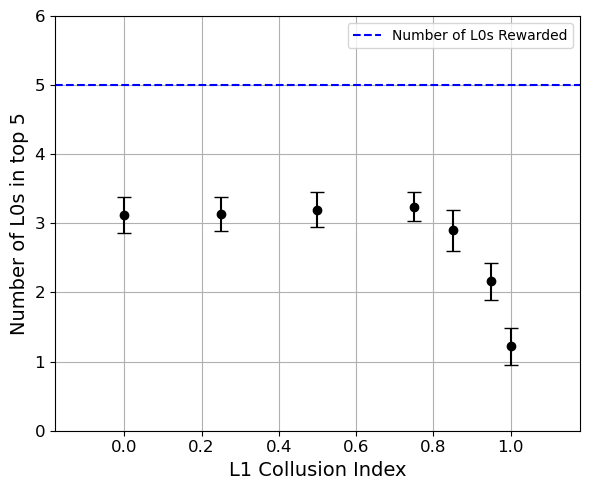

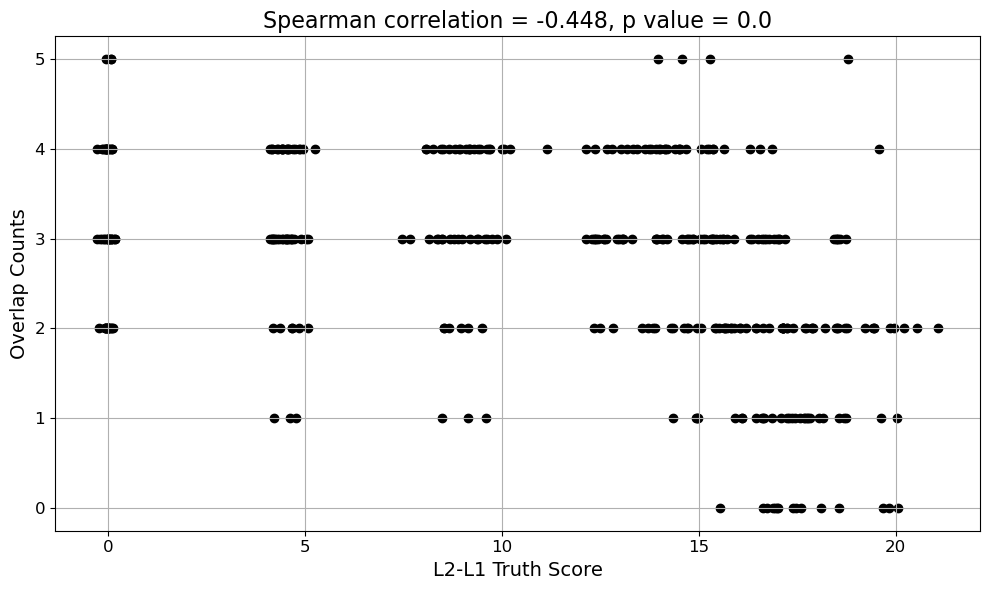

In [ ]:
n_simulations = 50
n_L0s_reward = 5
L1_collusion_index_list = [0, 0.25, 0.5, 0.75, 0.85, 0.95, 1]
#L1_collusion_index_list = [0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2]
#meas_error_std_dev_list = [0.1, 1, 10, 20, 30, 2, 5]
meas_error_std_dev_list = [1, 1, 1, 1, 1, 1, 1]
method = 'simple_difference'

scenario_parameters = {
    1: {
        'subjects_params': subjects_params,
        'passing_marks': passing_marks,
        'minimum_marks_mean': minimum_marks_mean,
        'minimum_marks_std_dev': minimum_marks_std_dev,
        'delta_mean': delta_mean,
        'delta_std_dev': delta_std_dev,
        'n_schools_per_L1': n_schools_per_L1,
        'measurement_error_mean': measurement_error_mean,
        'measurement_error_std_dev': meas_error_std_dev_list[0],
        'moderation_index_L1': moderation_index_L1,
        'L1_collusion_index': L1_collusion_index_list[0],
        
        'students_per_school': 20,
        'L1_retest_percentage': 50,
        'L2_retest_percentage_schools': 50,
        'L2_retest_percentage_students': 50,
        
    },
    2: {
        'subjects_params': subjects_params,
        'passing_marks': passing_marks,
        'minimum_marks_mean': minimum_marks_mean,
        'minimum_marks_std_dev': minimum_marks_std_dev,
        'delta_mean': delta_mean,
        'delta_std_dev': delta_std_dev,
        'n_schools_per_L1': n_schools_per_L1,
        'measurement_error_mean': measurement_error_mean,
        'measurement_error_std_dev': meas_error_std_dev_list[1],
        'moderation_index_L1': moderation_index_L1,
        'L1_collusion_index': L1_collusion_index_list[1],
        
        'students_per_school': 20,
        'L1_retest_percentage': 50,
        'L2_retest_percentage_schools': 50,
        'L2_retest_percentage_students': 50,
        
    },
    
    3: {
        'subjects_params': subjects_params,
        'passing_marks': passing_marks,
        'minimum_marks_mean': minimum_marks_mean,
        'minimum_marks_std_dev': minimum_marks_std_dev,
        'delta_mean': delta_mean,
        'delta_std_dev': delta_std_dev,
        'n_schools_per_L1': n_schools_per_L1,
        'measurement_error_mean': measurement_error_mean,
        'measurement_error_std_dev': meas_error_std_dev_list[2],
        'moderation_index_L1': moderation_index_L1,
        'L1_collusion_index': L1_collusion_index_list[2],
        
        'students_per_school': 20,
        'L1_retest_percentage': 50,
        'L2_retest_percentage_schools': 50,
        'L2_retest_percentage_students': 50,
        
    },
    4: {
        'subjects_params': subjects_params,
        'passing_marks': passing_marks,
        'minimum_marks_mean': minimum_marks_mean,
        'minimum_marks_std_dev': minimum_marks_std_dev,
        'delta_mean': delta_mean,
        'delta_std_dev': delta_std_dev,
        'n_schools_per_L1': n_schools_per_L1,
        'measurement_error_mean': measurement_error_mean,
        'measurement_error_std_dev': meas_error_std_dev_list[3],
        'moderation_index_L1': moderation_index_L1,
        'L1_collusion_index': L1_collusion_index_list[3],
        
        'students_per_school': 20,
        'L1_retest_percentage': 50,
        'L2_retest_percentage_schools': 50,
        'L2_retest_percentage_students': 50,
        
    },
    5: {
        'subjects_params': subjects_params,
        'passing_marks': passing_marks,
        'minimum_marks_mean': minimum_marks_mean,
        'minimum_marks_std_dev': minimum_marks_std_dev,
        'delta_mean': delta_mean,
        'delta_std_dev': delta_std_dev,
        'n_schools_per_L1': n_schools_per_L1,
        'measurement_error_mean': measurement_error_mean,
        'measurement_error_std_dev': meas_error_std_dev_list[4],
        'moderation_index_L1': moderation_index_L1,
        'L1_collusion_index': L1_collusion_index_list[4],
        
        'students_per_school': 20,
        'L1_retest_percentage': 50,
        'L2_retest_percentage_schools': 50,
        'L2_retest_percentage_students': 50,
        
    },
    6: {
        'subjects_params': subjects_params,
        'passing_marks': passing_marks,
        'minimum_marks_mean': minimum_marks_mean,
        'minimum_marks_std_dev': minimum_marks_std_dev,
        'delta_mean': delta_mean,
        'delta_std_dev': delta_std_dev,
        'n_schools_per_L1': n_schools_per_L1,
        'measurement_error_mean': measurement_error_mean,
        'measurement_error_std_dev': meas_error_std_dev_list[5],
        'moderation_index_L1': moderation_index_L1,
        'L1_collusion_index': L1_collusion_index_list[5],
        
        'students_per_school': 20,
        'L1_retest_percentage': 50,
        'L2_retest_percentage_schools': 50,
        'L2_retest_percentage_students': 50,
        
    },
    7: {
        'subjects_params': subjects_params,
        'passing_marks': passing_marks,
        'minimum_marks_mean': minimum_marks_mean,
        'minimum_marks_std_dev': minimum_marks_std_dev,
        'delta_mean': delta_mean,
        'delta_std_dev': delta_std_dev,
        'n_schools_per_L1': n_schools_per_L1,
        'measurement_error_mean': measurement_error_mean,
        'measurement_error_std_dev': meas_error_std_dev_list[6],
        'moderation_index_L1': moderation_index_L1,
        'L1_collusion_index': L1_collusion_index_list[6],
        
        'students_per_school': 20,
        'L1_retest_percentage': 50,
        'L2_retest_percentage_schools': 50,
        'L2_retest_percentage_students': 50,
        
    }
}

(n_real_L0s_mean, 
 n_real_L0s_ci, 
 L2_L1_truth_scores,
L0_real_truth_scores,
all_L2_L1_truth_scores,
all_overlap_counts) = edu_nested_simulation_functions.L1_reliability_scenario_wise(
    scenario_parameters, 
    n_L0s_reward,
    method, 
    n_simulations,
    #x_variable = meas_error_std_dev_list,
    #xlabel = 'Measurement Error Std. Dev.',
    x_variable = L1_collusion_index_list,
    xlabel = 'L1 Collusion Index',
    make_plots=True,
    xbuffer = 0.18)

### Predictability of L1 confidence based on L2-L1 truth score versus L1 collusion index

L1 collusion index: 0
     Measurement error std dev: 0.1
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 2
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 5
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest per

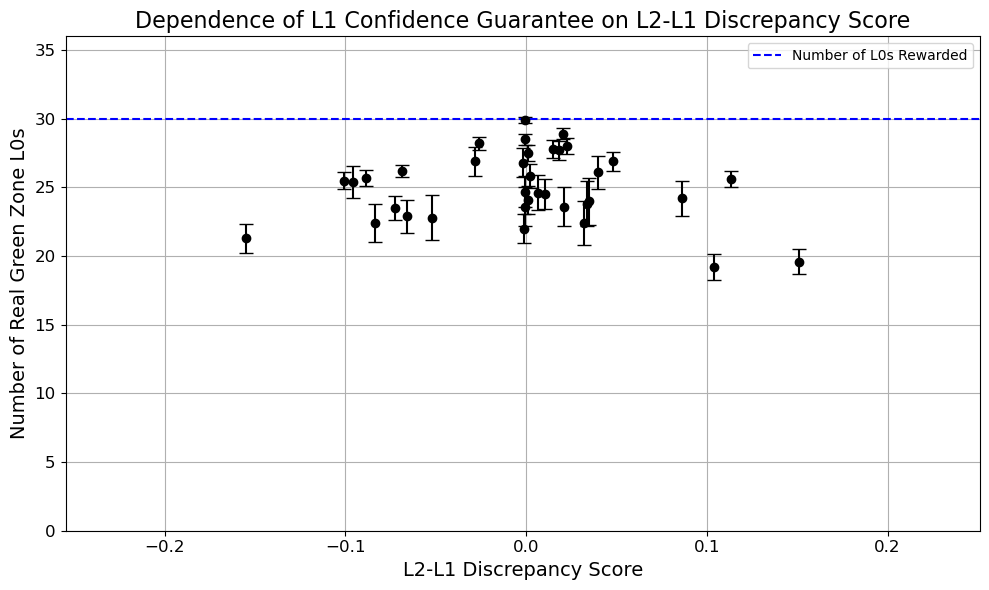

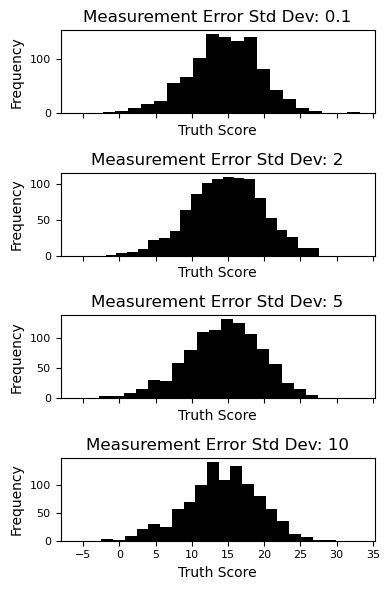

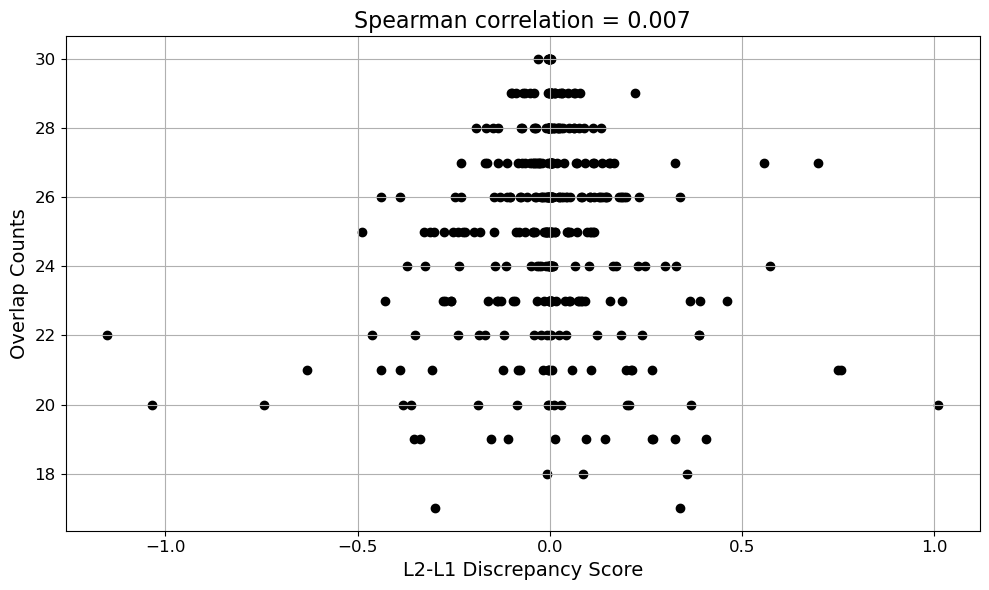

L1 collusion index: 0.2
     Measurement error std dev: 0.1
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 2
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 5
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest p

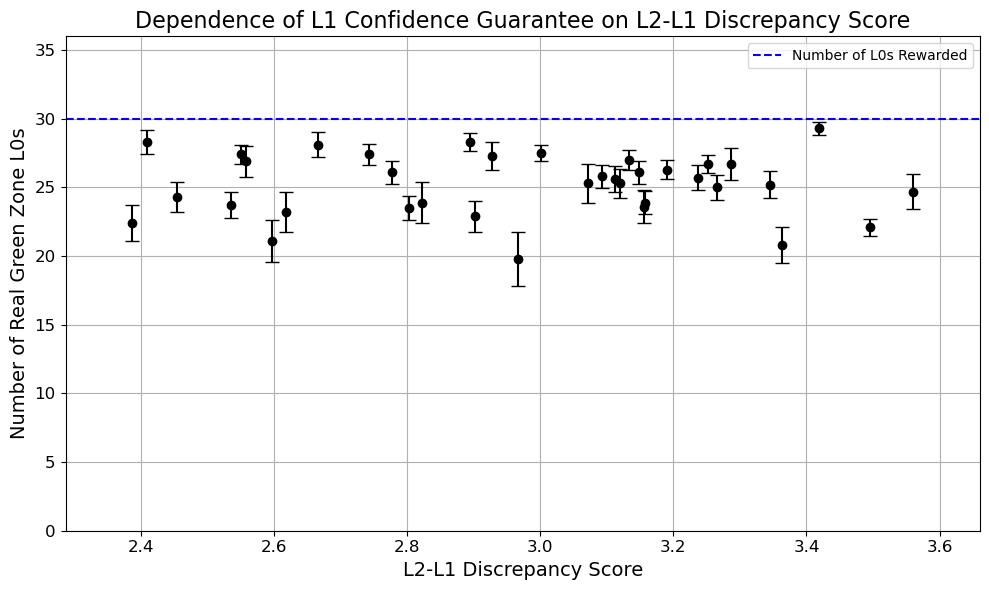

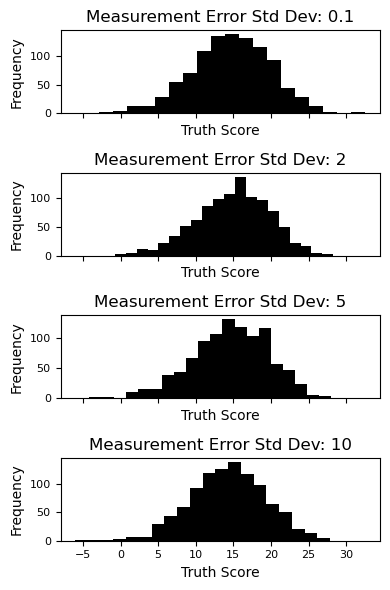

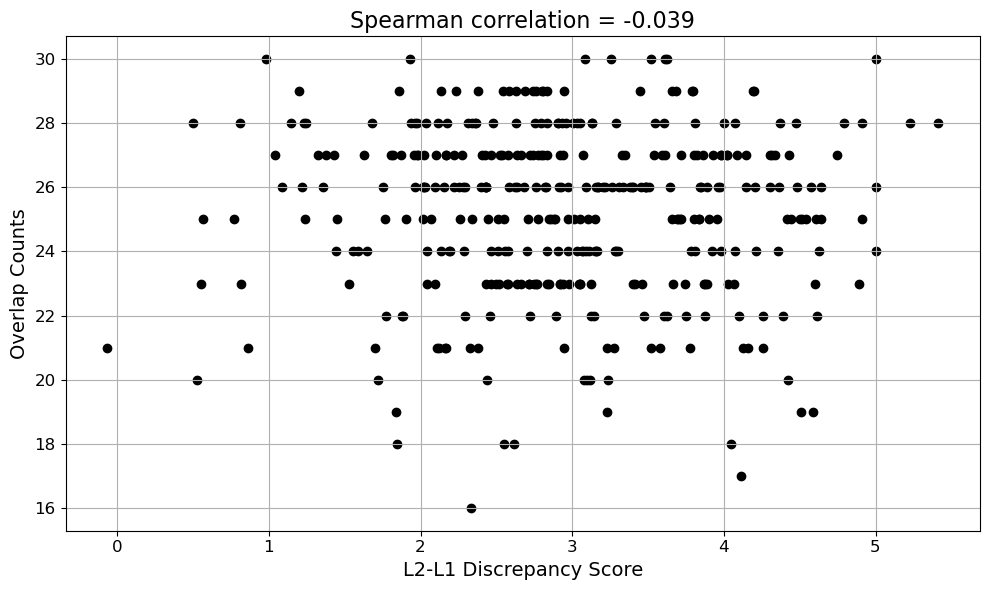

L1 collusion index: 0.4
     Measurement error std dev: 0.1
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 2
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 5
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest p

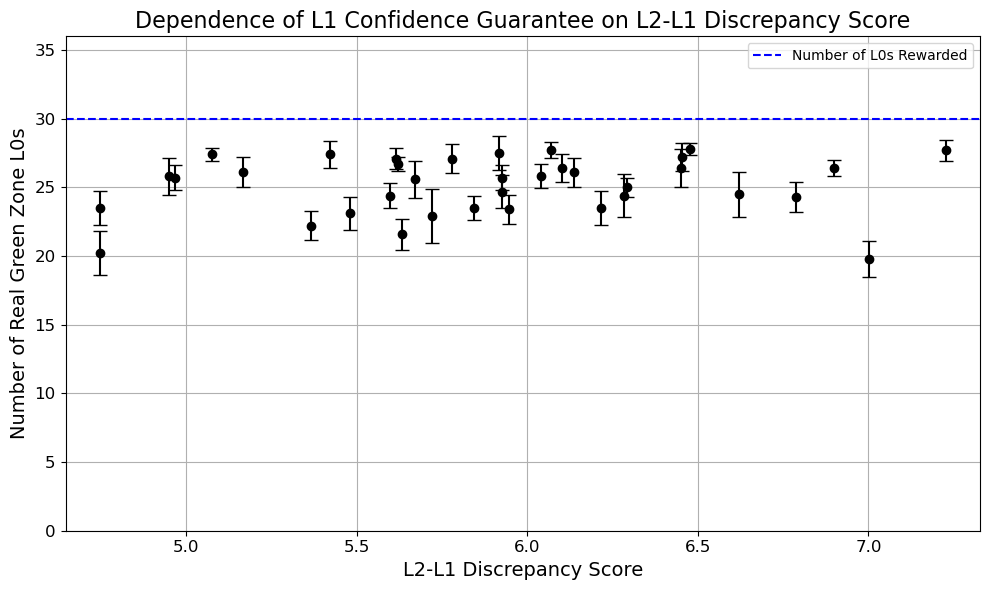

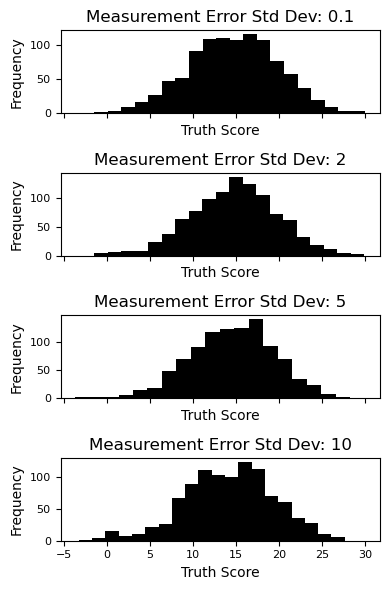

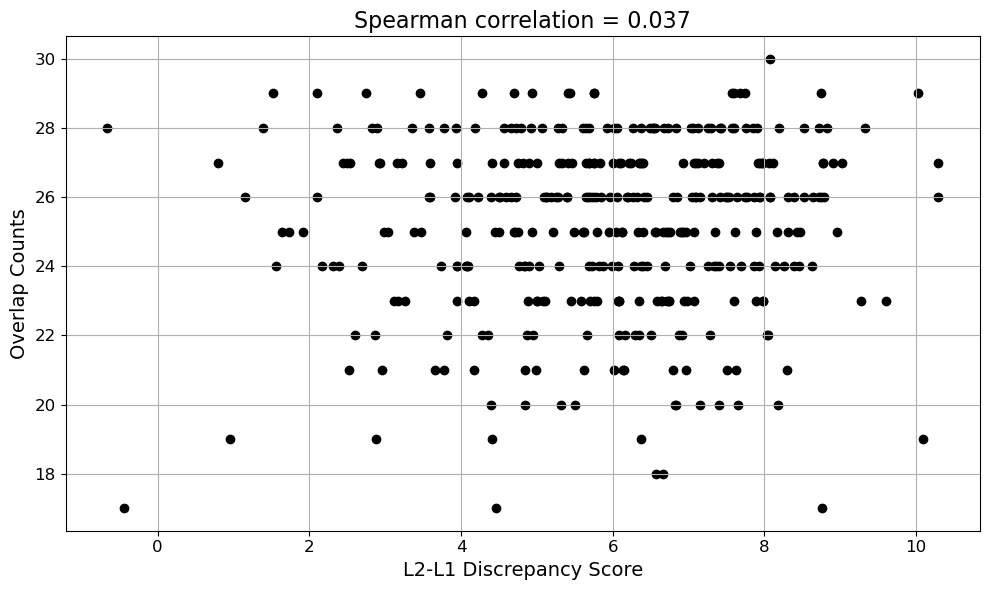

L1 collusion index: 0.5
     Measurement error std dev: 0.1
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 2
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 5
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest p

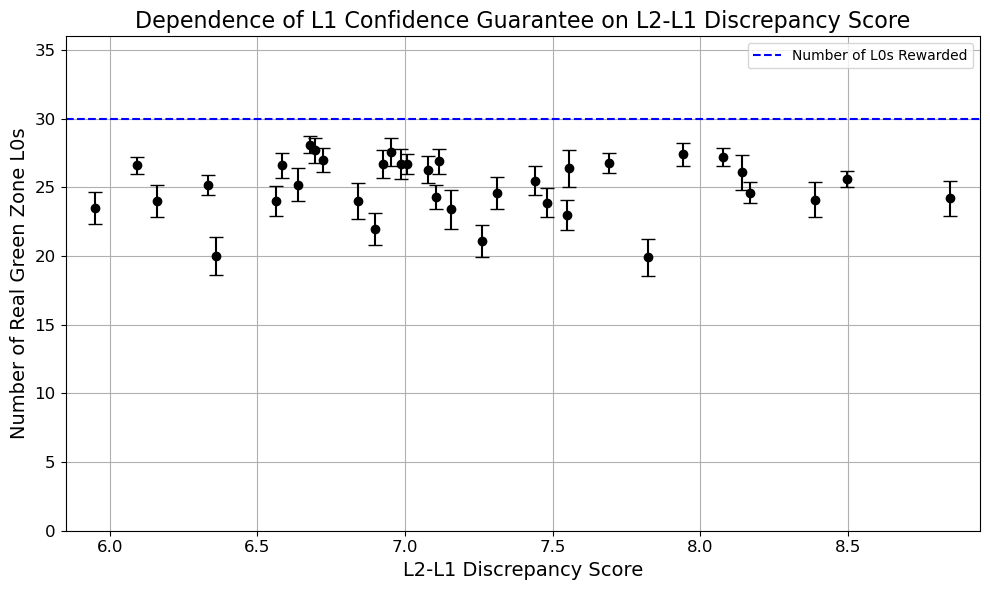

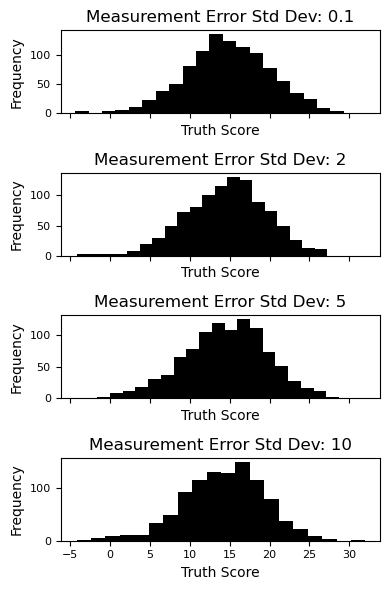

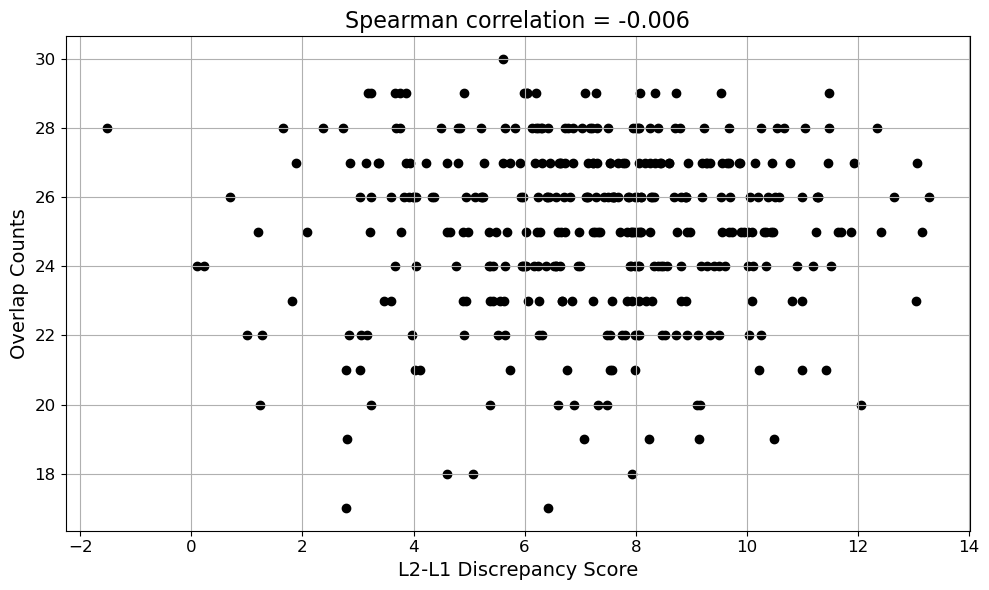

L1 collusion index: 0.6
     Measurement error std dev: 0.1
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 2
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 5
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest p

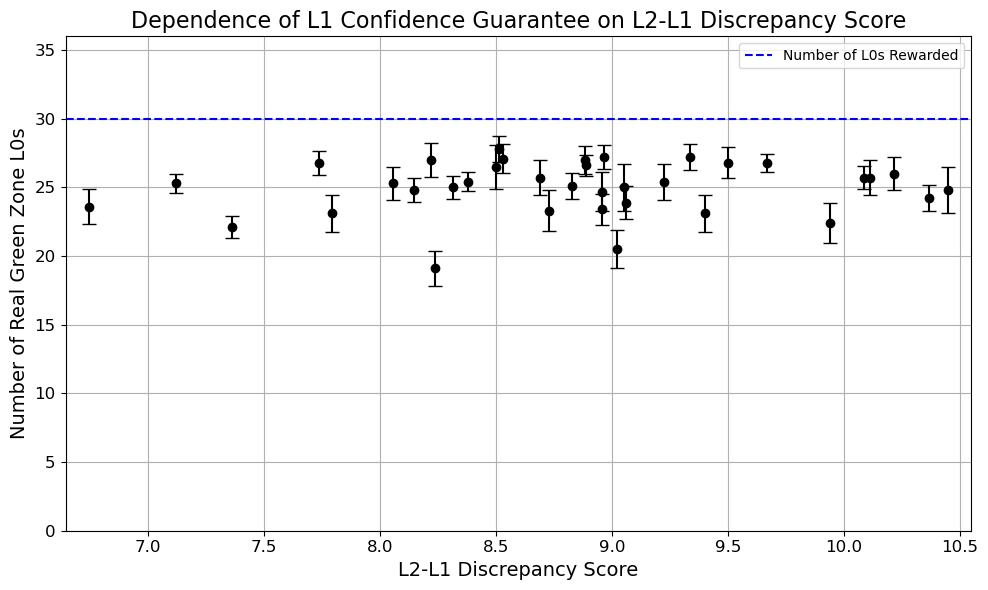

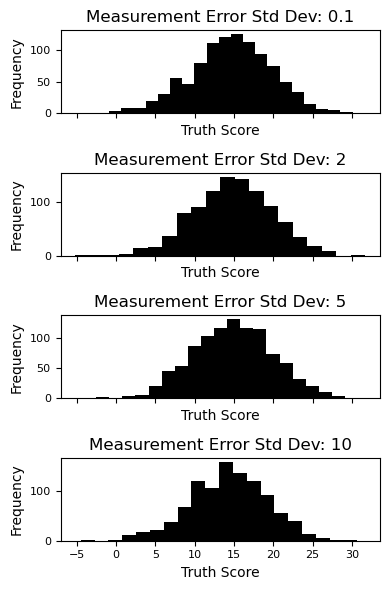

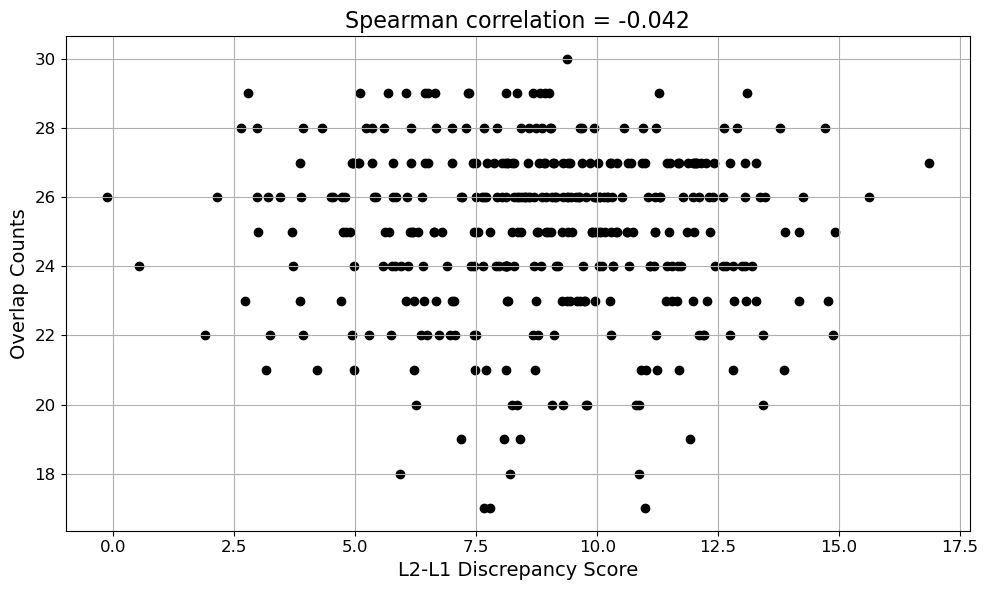

L1 collusion index: 0.7
     Measurement error std dev: 0.1
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 2
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 5
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest p

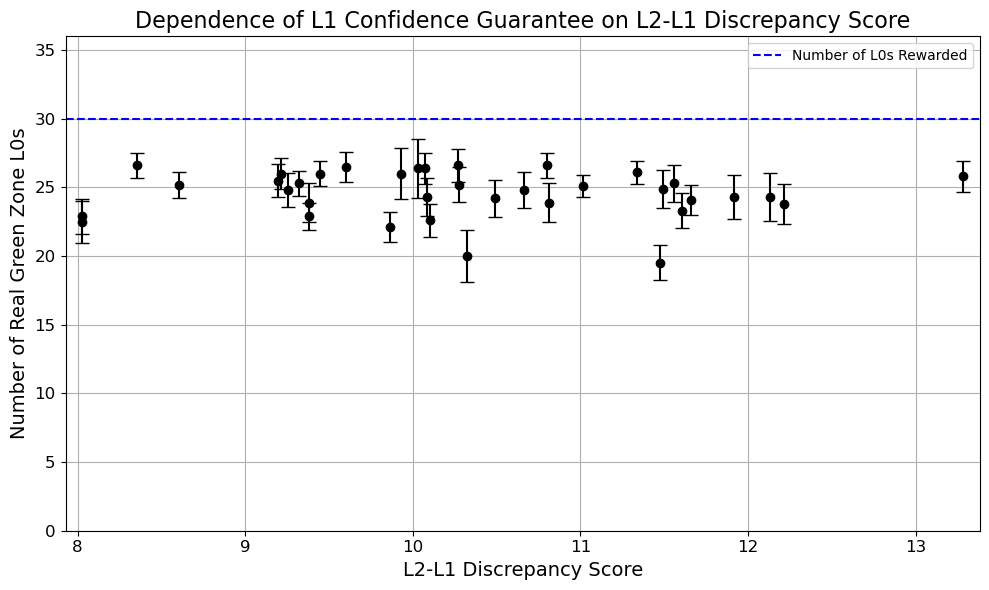

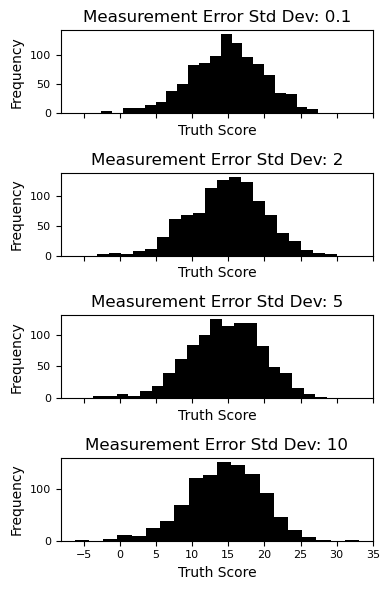

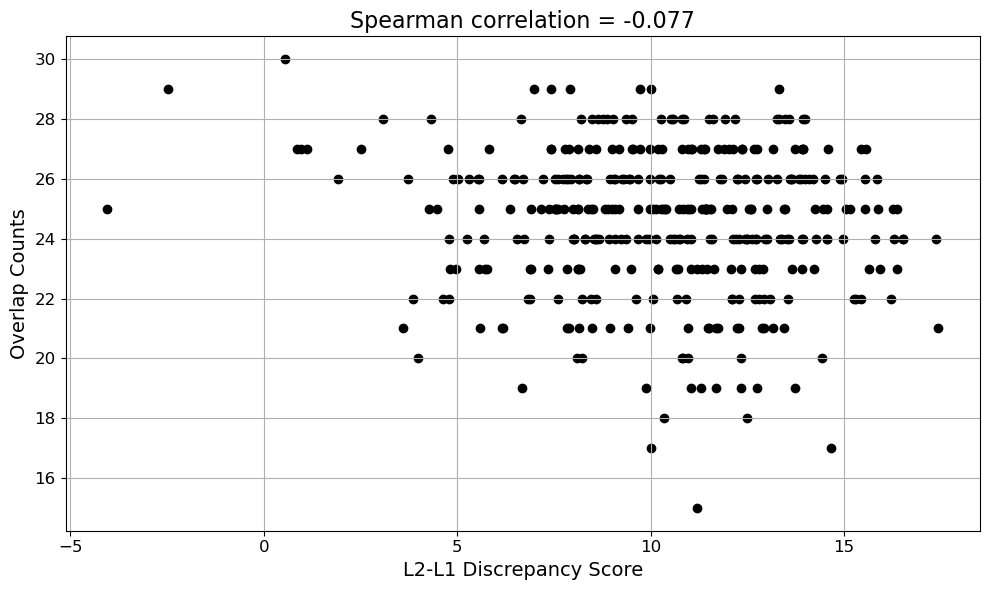

L1 collusion index: 0.8
     Measurement error std dev: 0.1
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 2
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 5
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest p

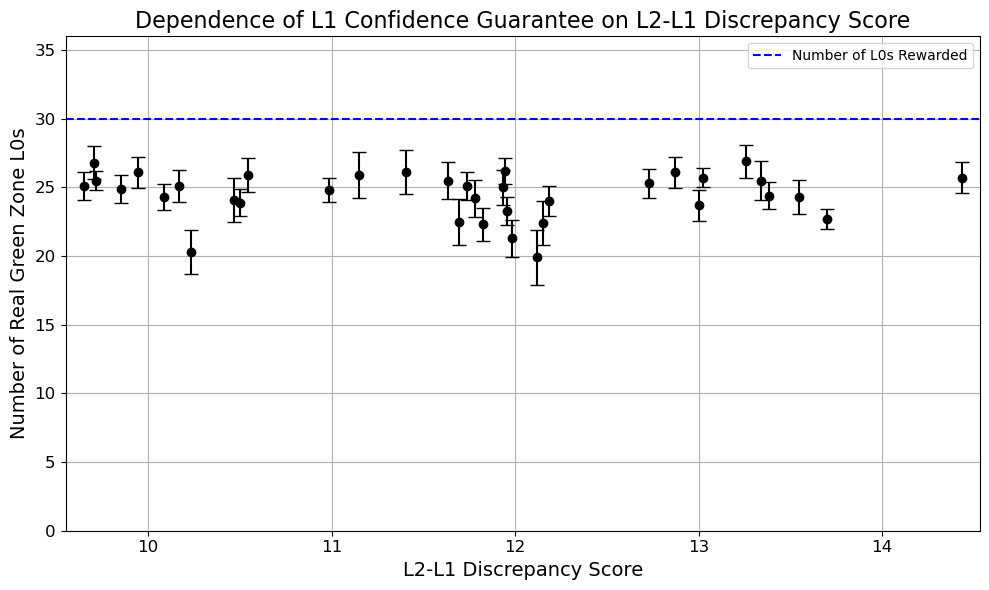

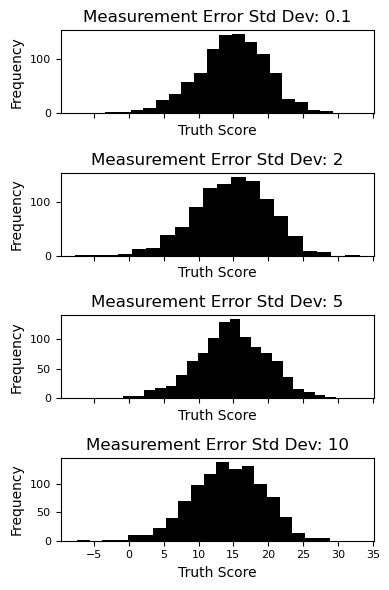

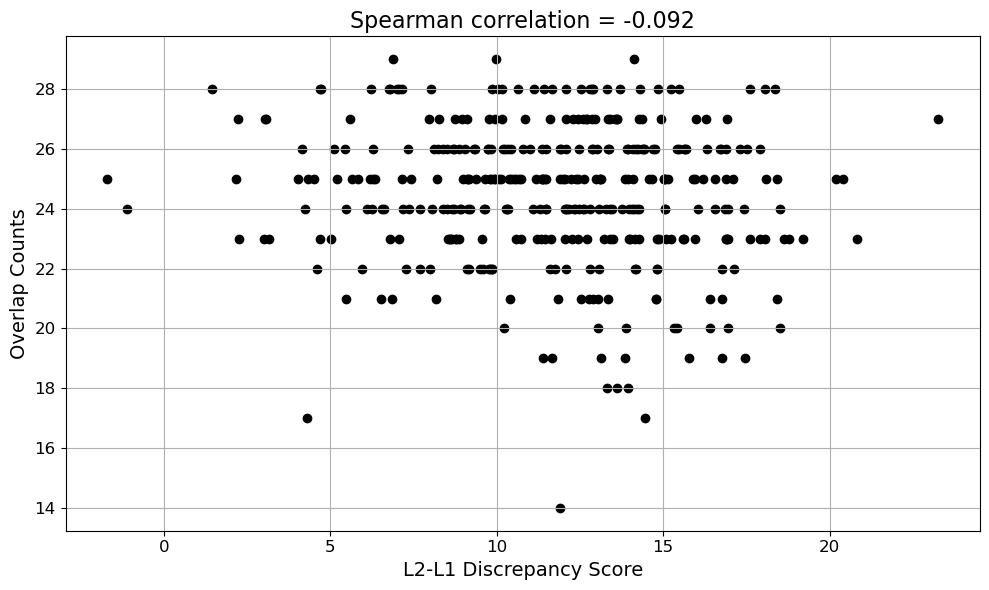

L1 collusion index: 1
     Measurement error std dev: 0.1
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 2
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest percentage: 90
         L1 retest percentage: 100
     Measurement error std dev: 5
         L1 retest percentage: 20
         L1 retest percentage: 30
         L1 retest percentage: 40
         L1 retest percentage: 50
         L1 retest percentage: 60
         L1 retest percentage: 70
         L1 retest percentage: 80
         L1 retest per

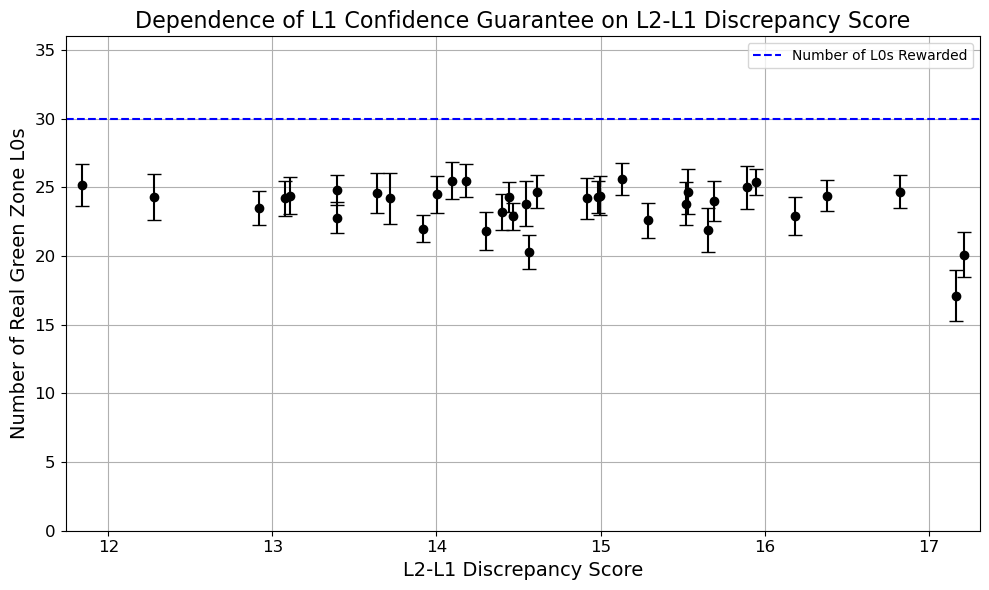

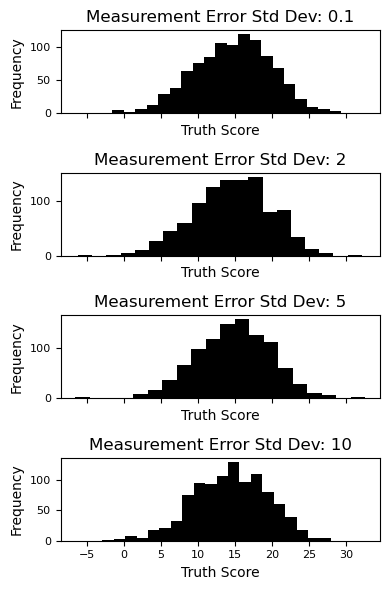

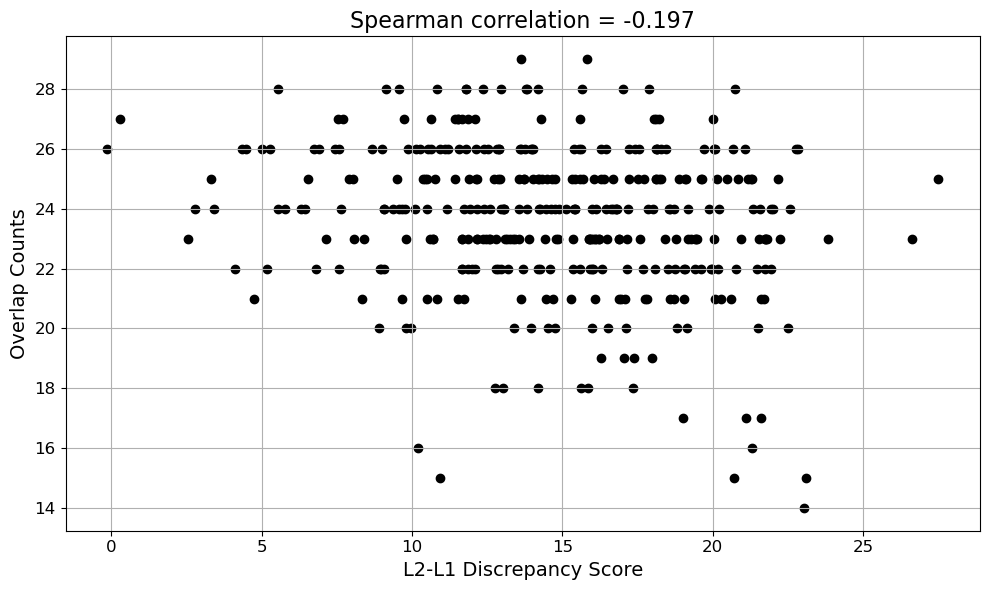

In [ ]:
n_schools_per_L1 = 100
n_L0s_reward = 30
L1_collusion_index_list = [0, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 1]
#L1_collusion_index_list = [0, 0.3, 0.5, 0.8, 0.9, 1]
#L1_collusion_index_list = [0, 1]

measurement_error_std_dev_list = [0.1, 2, 5, 10]
L1_retest_percentage_list = [20, 30, 40, 50, 60, 70, 80, 90, 100]
L2_retest_percentage_schools = 50
L2_retest_percentage_students = 100 # This is as a percentage of students tested by L1
n_simulations = 10

spearmann_correlations = []
p_values = []

for i in range(len(L1_collusion_index_list)):
    (n_real_L0s_mean, 
     n_real_L0s_ci, 
     L2_L1_truth_scores,
    L0_real_truth_scores,
    all_L2_L1_truth_scores,
    all_overlap_counts) = edu_nested_simulation_functions.L1_reliability([L1_collusion_index_list[i]], 
        students_per_school,
        subjects_params,
        passing_marks,
        minimum_marks_mean,
        minimum_marks_std_dev,
        delta_mean,
        delta_std_dev,
        n_schools_per_L1,
        L1_retest_percentage_list,
        L2_retest_percentage_schools,
        L2_retest_percentage_students,
        measurement_error_mean,
        measurement_error_std_dev_list,
        moderation_index_L1,
        method,
        n_L0s_reward,
        n_simulations,
        make_plots = True)
    
    #all_L2_L1_truth_scores = np.reshape(all_L2_L1_truth_scores, -1)
    #all_overlap_counts = np.reshape(all_overlap_counts, -1)
    spearmann_correlations.append(stats.spearmanr(all_L2_L1_truth_scores, all_overlap_counts)[0])
    p_values.append(stats.spearmanr(all_L2_L1_truth_scores, all_overlap_counts)[1])

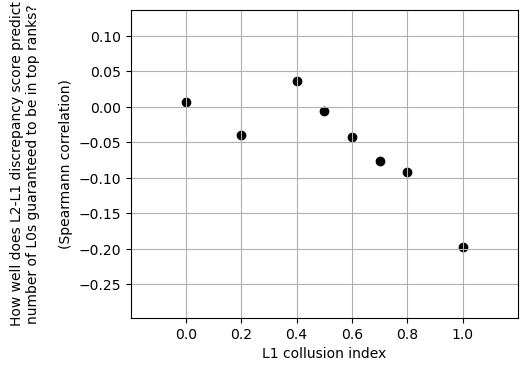

In [ ]:
plt.figure(figsize = [5, 4])
plt.scatter(L1_collusion_index_list, 
            spearmann_correlations, color = 'k', )
plt.xlabel('L1 collusion index')
plt.ylabel('How well does L2-L1 discrepancy score predict\nnumber of L0s guaranteed to be in top ranks?\n\n(Spearmann correlation)')
plt.xlim([-0.2, 1.2])
plt.ylim([np.min(spearmann_correlations) - 0.1, np.max(spearmann_correlations) + 0.1])
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
plt.grid()

In [ ]:
p_values

[0.8926233467380309,
 0.45880457390955476,
 0.487792465309,
 0.9094922715700133,
 0.4273852925171615,
 0.14733701984062963,
 0.0815778308841014,
 0.0001674413147026559]

# Early Childhood Development (ECD)

## Generate "ground truth" data

### Parameters

In [5]:
cd 

/Users/amritasingh


/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/.venv/lib/python3.9/site-packages/IPython/core/magics/osm.py:428: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
# Set parameters

num_children = 10000
girl_ratio = 0.5
num_timepoints = 1
time_lags = []
min_age = 0*365
max_age = 5*365

# Load HAZ parameters
filename = 'Documents{0}CEGIS{0}igrowup_WHO{0}igrowup_update{0}lenanthro.dta'.format(sep)
haz_params = extract_data_from_dta(filename)

# Load WAZ parameters
filename = 'Documents{0}CEGIS{0}igrowup_WHO{0}igrowup_update{0}weianthro.dta'.format(sep)
waz_params = extract_data_from_dta(filename)

# Load WHZ parameters
filename = 'Documents{0}CEGIS{0}igrowup_WHO{0}igrowup_update{0}wflanthro.dta'.format(sep)
whz_params_lying = extract_data_from_dta(filename)

filename = 'Documents{0}CEGIS{0}igrowup_WHO{0}igrowup_update{0}wfhanthro.dta'.format(sep)
whz_params_standing = extract_data_from_dta(filename)

### Main function call

/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/ecd_nested_simulation_functions/generate_ecd_dummy_data.py:168: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


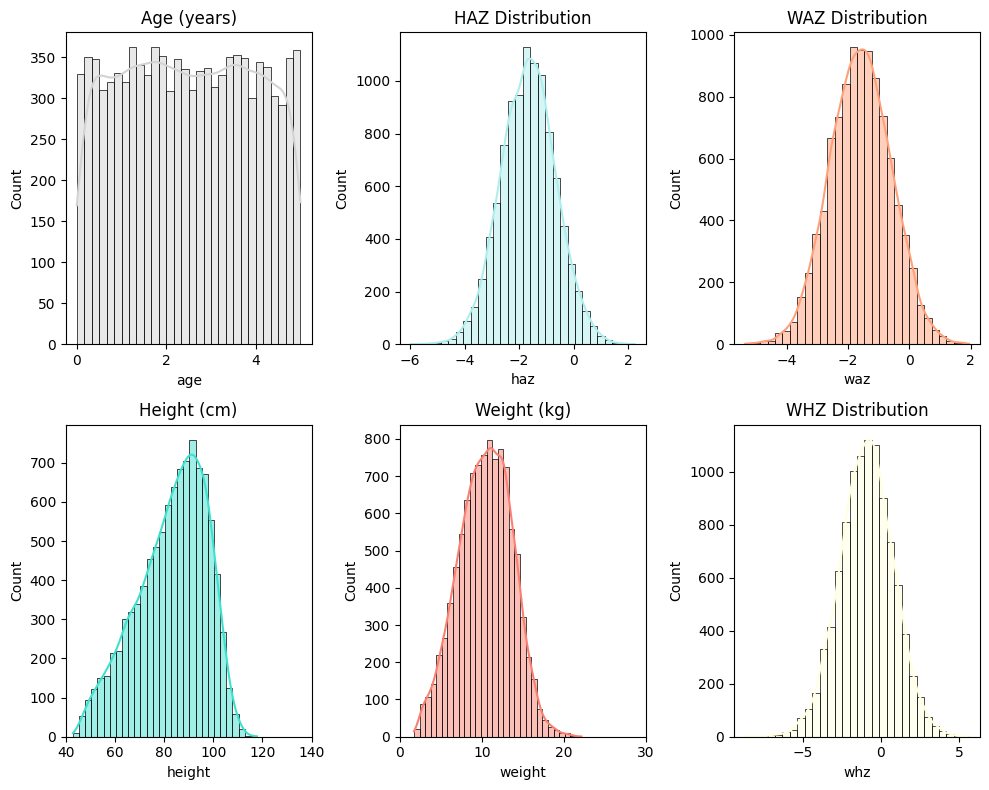

In [7]:
real_measurements = generate_ecd_dummy_data.generate_real_measurements(
    num_children,
    girl_ratio,
    num_timepoints,
    time_lags,
    min_age,
    max_age,
    haz_params,
    waz_params,
    whz_params_lying,
    whz_params_standing,
    haz_mean_0 = None,
    haz_std_0 = None,
    waz_mean_0 = None,
    waz_std_0 = None,
    percent_stunting = 36,
    percent_underweight = 34.2,
    min_height = None,
    max_height = None,
    min_weight=1,
    max_weight=30,
    plot_distributions = True,
    
)


### HAZ vs WAZ 2D histogram

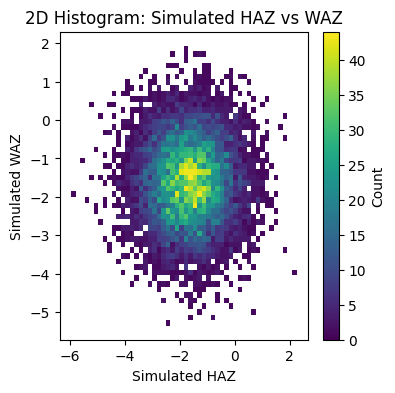

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(4, 4))
ax = sns.histplot(
    x=real_measurements['data']['haz'],
    y=real_measurements['data']['waz'],
    bins=50,
    cmap='viridis',
    cbar=True
)
cbar = ax.collections[0].colorbar
cbar.set_label('Count')
plt.xlabel('Simulated HAZ')
plt.ylabel('Simulated WAZ')
plt.title('2D Histogram: Simulated HAZ vs WAZ')
plt.show()

### % wasting for different values of % stunting and % underweight

#### Load state-wise percentages (Poshan Tracker and NFHS)

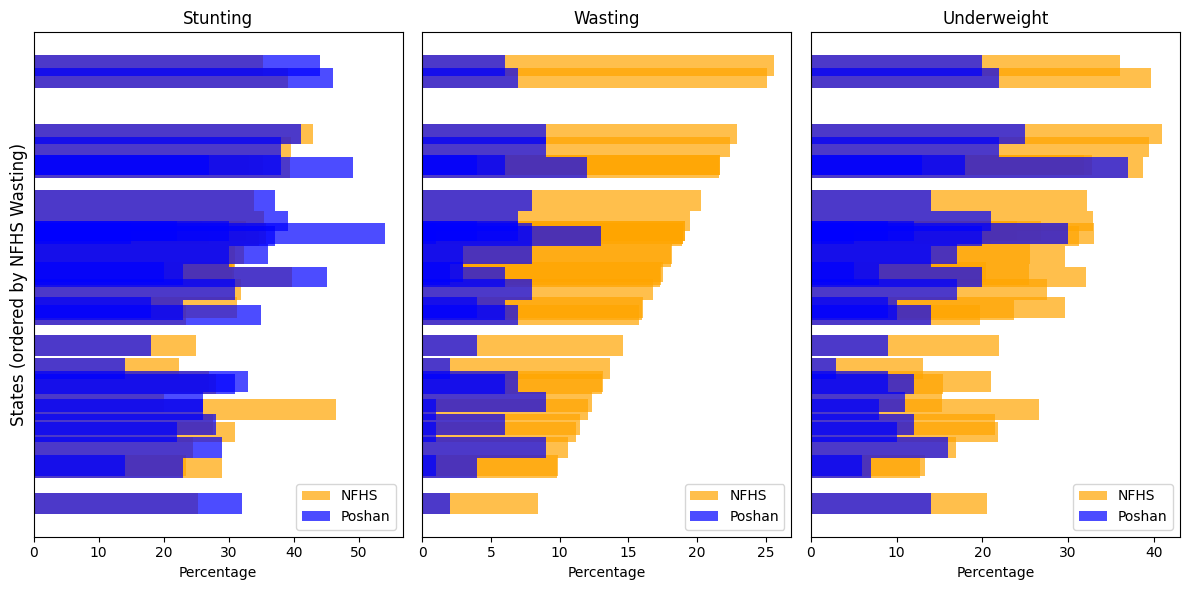

In [ ]:
state_wise_data = pd.read_csv('Documents{0}CEGIS{0}DiscSim_figures_and_data{0}250311_ECD_PTData (IDR Input) - PT_NFHS_States.csv'.format(sep),
                              skiprows = 1, nrows = 35)

# Extract percentages for each state
poshan_stunting = state_wise_data['PStunting (in %)'].values
poshan_underweight = state_wise_data['PUnderweight (in %)'].values
poshan_wasting = state_wise_data['PWasting  (in %)'].values

nfhs_stunting = state_wise_data['NFStunting (in %)'].values
nfhs_underweight = state_wise_data['NFUnderweight (in %)'].values
nfhs_wasting = state_wise_data['NFWasting  (in %)'].values

order = np.sort(nfhs_wasting)

# Plot stunting, wasting and underweight from poshan tracker data and NFHS data for all states ordered by NFHS wasting
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.barh(order, nfhs_stunting[np.argsort(nfhs_wasting)], color='orange', alpha=0.7, label='NFHS')
plt.barh(order, poshan_stunting[np.argsort(nfhs_wasting)], color='blue', alpha=0.7, label='Poshan')
plt.title('Stunting')
plt.xlabel('Percentage')
plt.ylabel('States (ordered by NFHS Wasting)', fontsize = 12)
plt.yticks([])
plt.legend()

plt.subplot(1, 3, 2, sharey = plt.subplot(1, 3, 1))
plt.barh(order, nfhs_wasting[np.argsort(nfhs_wasting)], color='orange', alpha=0.7, label='NFHS')
plt.barh(order, poshan_wasting[np.argsort(nfhs_wasting)], color='blue', alpha=0.7, label='Poshan')
plt.title('Wasting')
plt.xlabel('Percentage')
plt.legend()

plt.subplot(1, 3, 3, sharey = plt.subplot(1, 3, 1))
plt.barh(order, nfhs_underweight[np.argsort(nfhs_wasting)], color='orange', alpha=0.7, label='NFHS')
plt.barh(order, poshan_underweight[np.argsort(nfhs_wasting)], color='blue', alpha=0.7, label='Poshan')
plt.title('Underweight')
plt.xlabel('Percentage')
plt.legend()

plt.tight_layout()
plt.show()

#### Simulate ground truth data for each combination of % stunting and % underweight

In [ ]:
sim_wasting_poshan = []
sim_wasting_nfhs = []

print('Simulation with Poshan Tracker data values')
for st, uw in tqdm(zip(poshan_stunting, poshan_underweight)):
    real_data = ecd_nested_simulation_functions.generate_real_measurements(
        num_children,
        girl_ratio,
        num_timepoints,
        time_lags,
        min_age,
        max_age,
        haz_params=haz_params,
        waz_params=waz_params,
        whz_params_lying=whz_params_lying,
        whz_params_standing=whz_params_standing,
        percent_stunting=st,
        percent_underweight=uw,
        min_height=None,
        max_height=None,
        min_weight=1,
        max_weight=30,
        plot_distributions=False
    )
    sim_wasting_poshan.append(real_data['metadata']['percent_wasting'])

print('\n\nSimulation with NFHS data values')
for st, uw in tqdm(zip(nfhs_stunting, nfhs_underweight)):
    real_data = ecd_nested_simulation_functions.generate_real_measurements(
        num_children,
        girl_ratio,
        num_timepoints,
        time_lags,
        min_age,
        max_age,
        haz_params=haz_params,
        waz_params=waz_params,
        whz_params_lying=whz_params_lying,
        whz_params_standing=whz_params_standing,
        percent_stunting=st,
        percent_underweight=uw,
        min_height=None,
        max_height=None,
        min_weight=1,
        max_weight=30,
        plot_distributions=False
    )
    sim_wasting_nfhs.append(real_data['metadata']['percent_wasting'])


Simulation with Poshan Tracker data values


0it [00:00, ?it/s]

10000it [00:02, 3727.84it/s]
10000it [00:02, 3724.15it/s]
4003it [00:00, 75042.57it/s]
5997it [00:00, 74640.69it/s]
0it [00:05, ?it/s]


13.919999999999998% wasting


AttributeError: 'numpy.float64' object has no attribute 'iloc'

#### Plot heatmaps

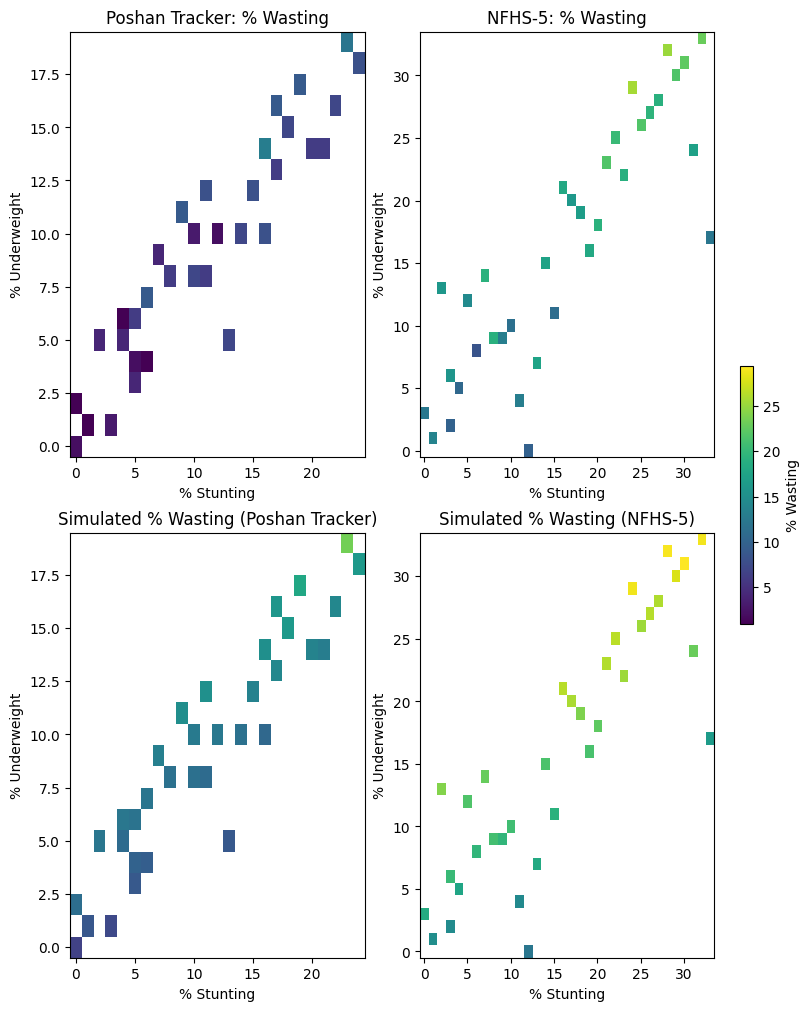

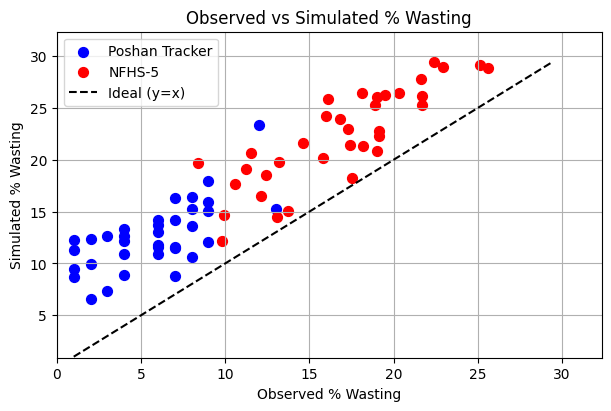

In [ ]:
# Prepare data for heatmaps
def prepare_heatmap(x, y, z):
    # Create grid for heatmap
    xi = np.unique(x)
    yi = np.unique(y)
    grid = np.full((len(yi), len(xi)), np.nan)
    for i in range(len(x)):
        x_idx = np.where(xi == x[i])[0][0]
        y_idx = np.where(yi == y[i])[0][0]
        grid[y_idx, x_idx] = z[i]
    return xi, yi, grid

# Heatmap data
xi_p, yi_p, grid_p_wasting = prepare_heatmap(poshan_stunting, poshan_underweight, poshan_wasting)
xi_n, yi_n, grid_n_wasting = prepare_heatmap(nfhs_stunting, nfhs_underweight, nfhs_wasting)
xi_p, yi_p, grid_sim_p_wasting = prepare_heatmap(poshan_stunting, poshan_underweight, sim_wasting_poshan)
xi_n, yi_n, grid_sim_n_wasting = prepare_heatmap(nfhs_stunting, nfhs_underweight, sim_wasting_nfhs)

# Set common colorbar limits
all_wasting = np.concatenate([grid_p_wasting.flatten(), grid_n_wasting.flatten(), grid_sim_p_wasting.flatten(), grid_sim_n_wasting.flatten()])
vmin = np.nanmin(all_wasting)
vmax = np.nanmax(all_wasting)

fig, axs = plt.subplots(2, 2, figsize=(8, 10), constrained_layout = True)
im1 = axs[0, 0].imshow(grid_p_wasting, origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
axs[0, 0].set_title('Poshan Tracker: % Wasting')
axs[0, 0].set_xlabel('% Stunting')
axs[0, 0].set_ylabel('% Underweight')

im2 = axs[0, 1].imshow(grid_n_wasting, origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
axs[0, 1].set_title('NFHS-5: % Wasting')
axs[0, 1].set_xlabel('% Stunting')
axs[0, 1].set_ylabel('% Underweight')

im3 = axs[1, 0].imshow(grid_sim_p_wasting, origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
axs[1, 0].set_title('Simulated % Wasting (Poshan Tracker)')
axs[1, 0].set_xlabel('% Stunting')
axs[1, 0].set_ylabel('% Underweight')

im4 = axs[1, 1].imshow(grid_sim_n_wasting, origin='lower', aspect='auto', vmin=vmin, vmax=vmax)
axs[1, 1].set_title('Simulated % Wasting (NFHS-5)')
axs[1, 1].set_xlabel('% Stunting')
axs[1, 1].set_ylabel('% Underweight')

# Add a single colorbar for all plots
fig.colorbar(im1, ax=axs, orientation='vertical', fraction=0.02, pad=0.04, label='% Wasting')

plt.show()

# Scatter plot: real vs simulated wasting
plt.figure(figsize=(6, 4), constrained_layout=True)
plt.scatter(poshan_wasting, sim_wasting_poshan, color='blue', label='Poshan Tracker', s=50)
plt.scatter(nfhs_wasting, sim_wasting_nfhs, color='red', label='NFHS-5', s=50)
plt.plot([vmin, vmax], [vmin, vmax], 'k--', label='Ideal (y=x)')
plt.xlabel('Observed % Wasting')
plt.ylabel('Simulated % Wasting')
plt.title('Observed vs Simulated % Wasting')
plt.legend()
plt.grid(True)
plt.xlim([0, vmax*1.1])
plt.ylim([vmin*0.9, vmax*1.1])
plt.show()

## Generate L0 distorted data

/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/ecd_nested_simulation_functions/generate_ecd_dummy_data.py:428: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


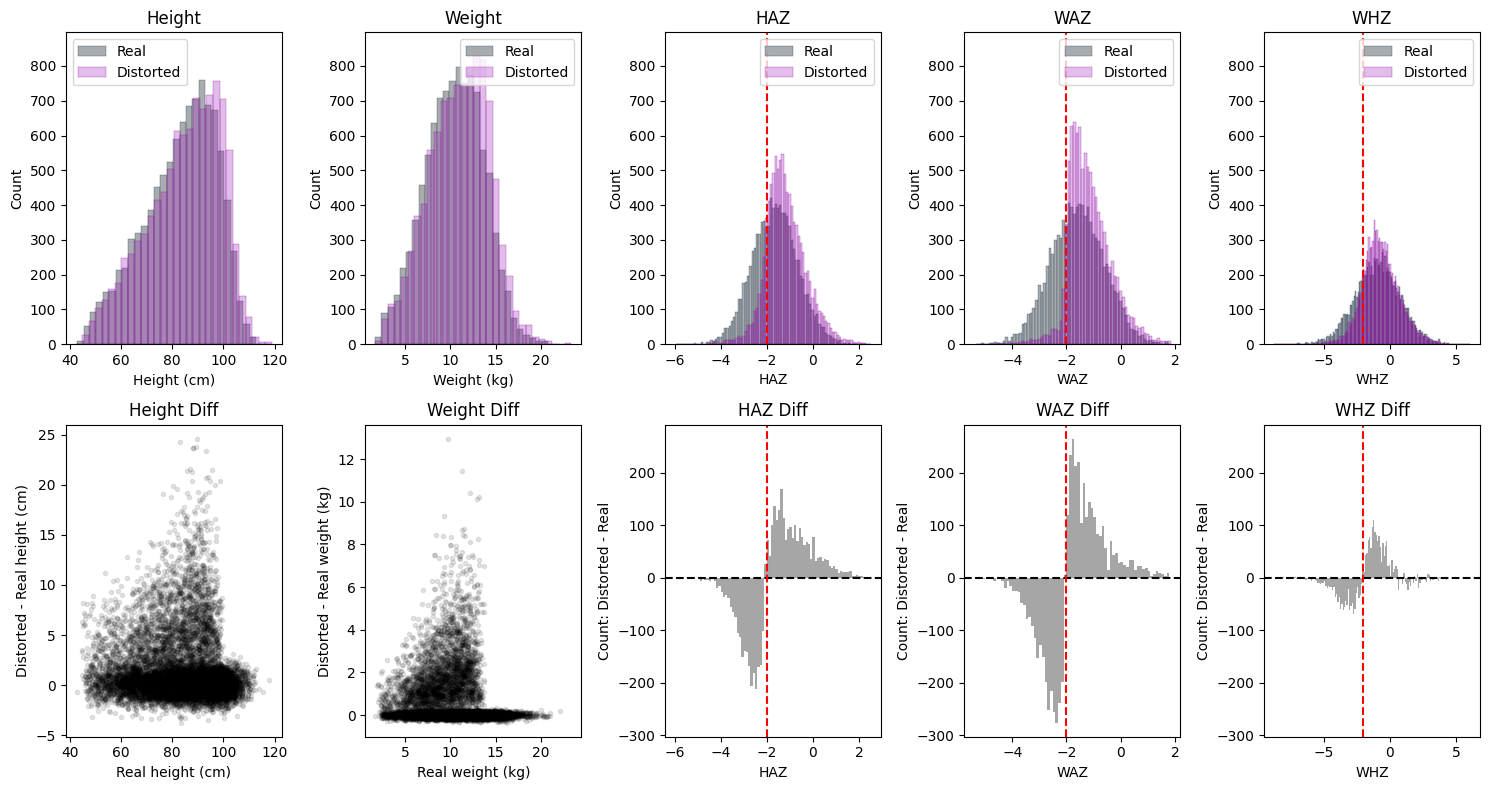

In [10]:
percent_under_reporting_stunting = 30
percent_under_reporting_underweight = 30

L0_distorted_measurements = generate_ecd_dummy_data.generate_L0_distorted_measurements(
    real_measurements=real_measurements,
    haz_params=haz_params,
    waz_params=waz_params,
    whz_params_lying=whz_params_lying,
    whz_params_standing=whz_params_standing,
    percent_under_reporting_stunting=percent_under_reporting_stunting,
    percent_under_reporting_underweight=percent_under_reporting_underweight,
    bin_size = 0.1,
    bunch_factor_haz=0.1,
    bunch_factor_waz=0.1,
    bunch_factor_whz=0.1,
    error_mean_height=0,
    error_sd_height=1,
    error_mean_weight=0,
    error_sd_weight=0.1,
    make_plots= True
)


## Generate L1 distorted data

### Main function call

/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/ecd_nested_simulation_functions/generate_ecd_dummy_data.py:827: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


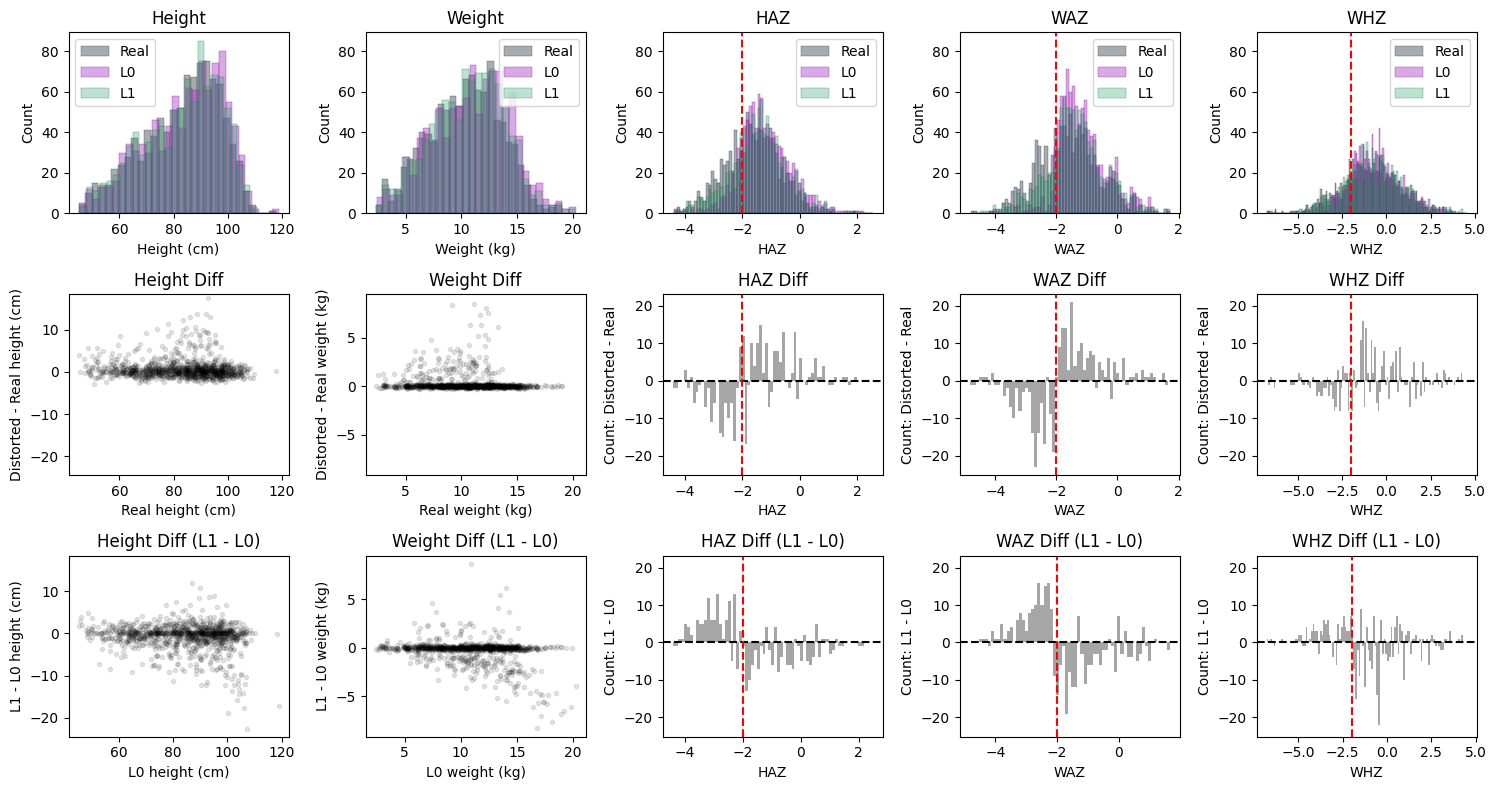

In [11]:
percent_copy = 10
collusion_index = 0.5
num_children_L1 = 1000

L1_distorted_measurements = generate_ecd_dummy_data.generate_L1_distorted_measurements(
        real_measurements,
        L0_distorted_measurements,
        haz_params,
        waz_params,
        whz_params_lying,
        whz_params_standing,
        num_children_L1,
        percent_copy,
        collusion_index,
        error_mean_height = 0,
        error_sd_height = 1,
        error_mean_weight = 0,
        error_sd_weight = 0.1,
        bunch_factor_haz = 0.1,
        bunch_factor_waz = 0.1,
        bunch_factor_whz = 0.1,
        bin_size = 0.1,
        make_plots = True, figsize = [15, 8]
        )

## Generate L2 distorted data

/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/ecd_nested_simulation_functions/generate_ecd_dummy_data.py:1031: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


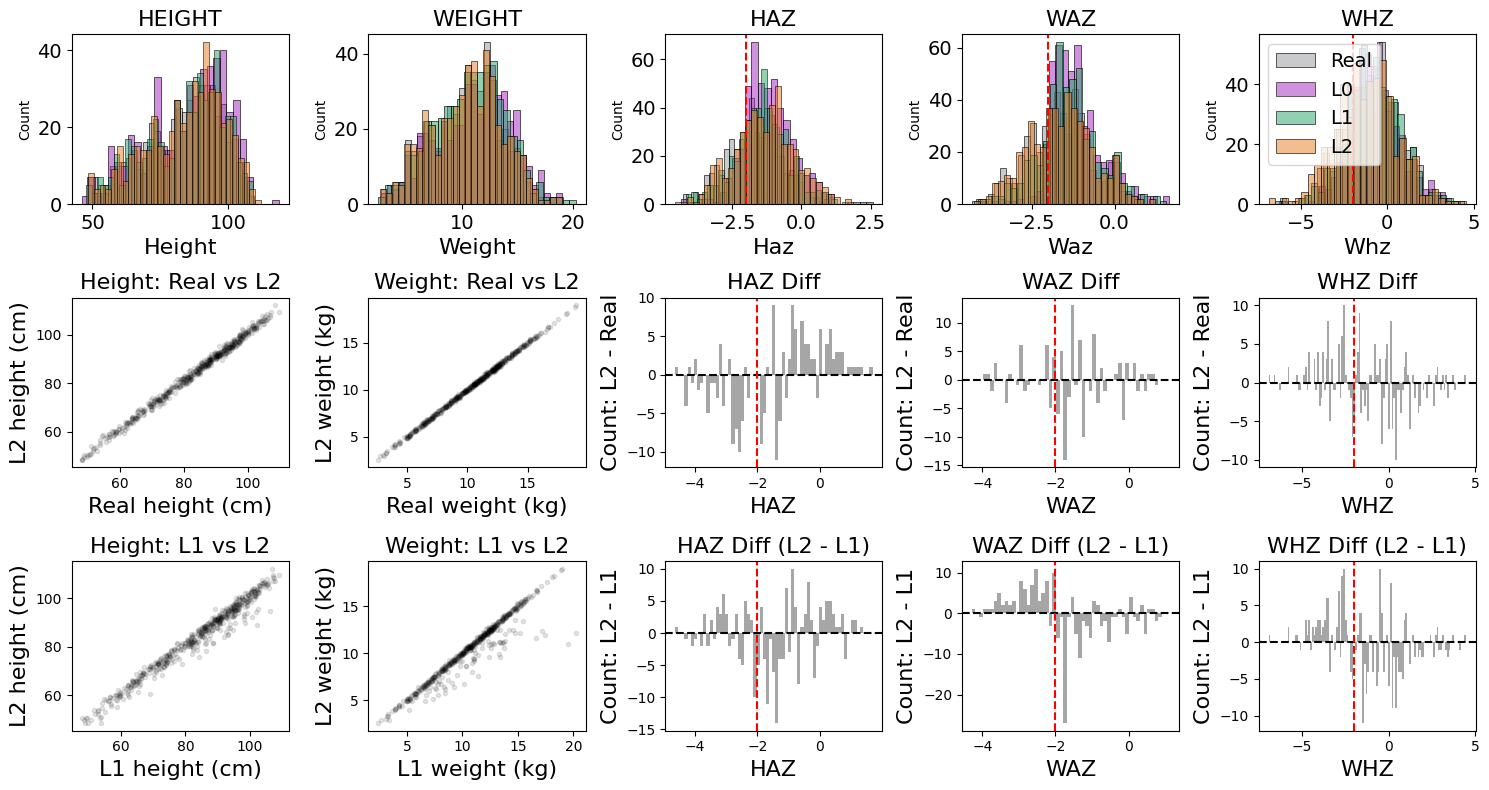

In [12]:
num_children_L2 = 500

L2_distorted_measurements = generate_ecd_dummy_data.generate_L2_distorted_measurements(
    real_measurements=real_measurements,
    L0_measurements=L0_distorted_measurements,
    L1_measurements=L1_distorted_measurements,
    haz_params=haz_params,
    waz_params=waz_params,
    whz_params_lying=whz_params_lying,
    whz_params_standing=whz_params_standing,
    num_children_L2=num_children_L2,  # Set as needed
    error_mean_height=0,
    error_sd_height=1,
    error_mean_weight=0,
    error_sd_weight=0.1,
    drift_mean_height=1,
    drift_sd_height=0.5,
    drift_mean_weight=0,
    drift_sd_weight=0.05,
    reporting_threshold=-2,
    figsize=[15, 8],
    make_plots=True
)

## Calculate discrepancy scores

### Real discrepancy - L0 distorted measurement vs real measurements

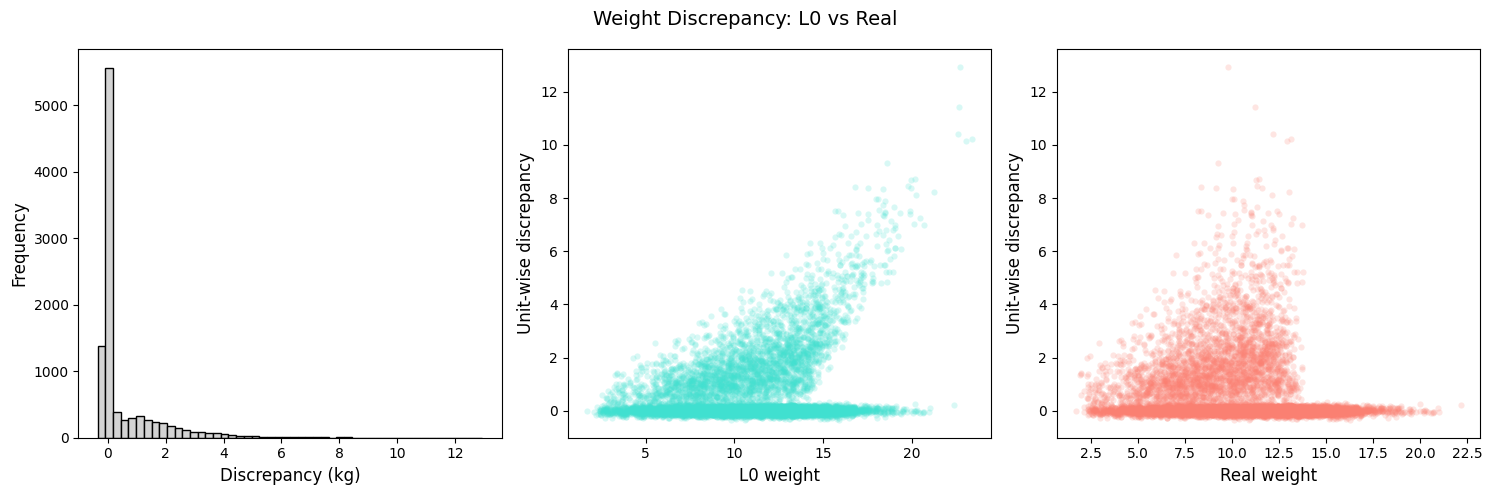

In [14]:

disc_scores = ecd_sampling_strategy.calculate_discrepancy_scores(
    L0_distorted_measurements['data'], 
    real_measurements['data'], 
    'weight',
    'simple_difference',
    make_plot=True,
    plot_title='Weight Discrepancy: L0 vs Real',
    measurements1_name='L0',
    measurements2_name='Real',
    discrepancy_unit='kg'
)

### Measured discrepancy - L1 distorted measurement vs L0 distorted measurement

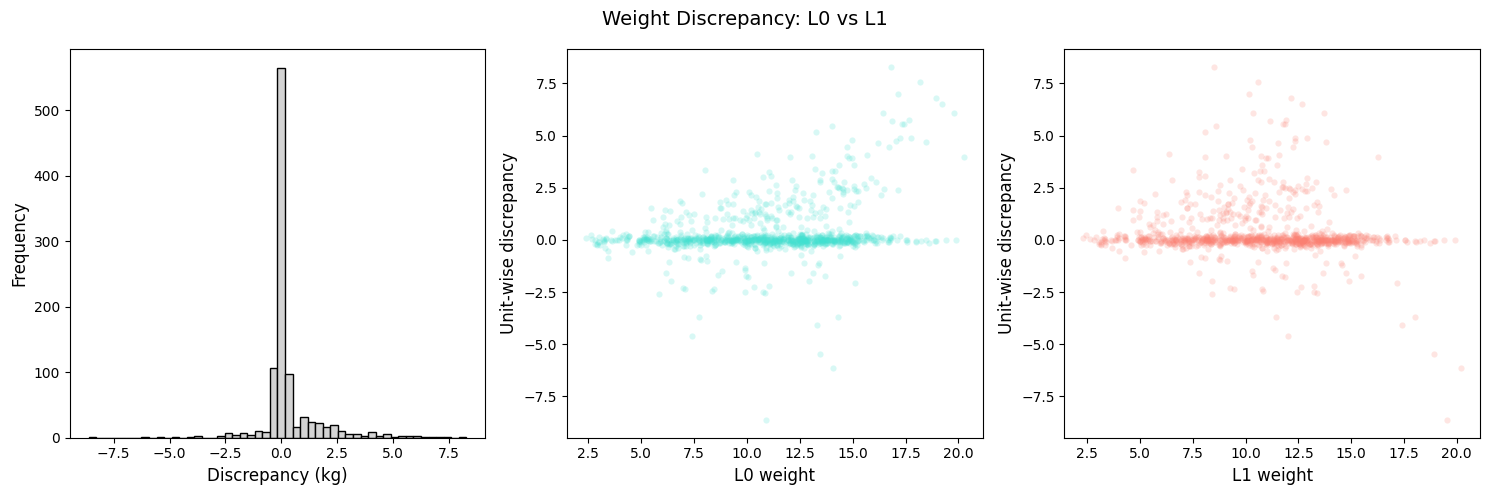

In [15]:
# Create measurements dictionary for real and L0 measurements with only those children who are tested by L1
L1_indices = L1_distorted_measurements['data'].index
real_subset_L1 = {
    'data': real_measurements['data'].loc[L1_indices].copy(),
    'metadata': real_measurements['metadata'].copy()
}
L0_subset_L1 = {
    'data': L0_distorted_measurements['data'].loc[L1_indices].copy(),
    'metadata': L0_distorted_measurements['metadata'].copy()
}
disc_scores = ecd_sampling_strategy.calculate_discrepancy_scores(
    L0_subset_L1['data'], 
    L1_distorted_measurements['data'], 
    'weight',
    'simple_difference',
    make_plot=True,
    plot_title='Weight Discrepancy: L0 vs L1',
    measurements1_name='L0',
    measurements2_name='L1',
    discrepancy_unit='kg'
)

## Sampling strategy selection based on ranking of blocks (as for Edu on VALIData)

### Generate nested measurements - real, L0, L1, L2

In [23]:
# Define parameters
real_params = {'girl_ratio': 0.5,
 'num_timepoints': 1,
 'time_lags': [],
 'min_age': 0,
 'max_age': 1825,
 'percent_stunting': 36,
 'percent_underweight': 34.2}

L0_params_list, L1_params_list, L2_params_dict = generate_ecd_dummy_data.generate_nested_distortion_parameters(
    n_L1s = 5, 
    n_L0s_per_L1 = 10,
    # Real percentages
    real_percent_stunting=36,
    real_percent_underweight=34.2,
    real_percent_wasting=None,
    # L0 parameter means
    mean_percent_under_reporting_stunting=30,
    mean_percent_under_reporting_underweight=30,
    mean_percent_under_reporting_wasting=None,
    mean_bunch_factor_haz=0.1,
    mean_bunch_factor_waz=0.1,
    mean_bunch_factor_whz=0.1,
    error_mean_height_all_L0s = 0,
    error_sd_height_all_L0s = 1,
    error_mean_weight_all_L0s = 0,
    error_sd_weight_all_L0s = 0.1,
    # L0 parameter standard deviations across units
    sd_across_units_percent_under_reporting_stunting=5,
    sd_across_units_percent_under_reporting_underweight=5,
    sd_across_units_percent_under_reporting_wasting=5,
    sd_across_units_bunch_factor_haz=0.02,
    sd_across_units_bunch_factor_waz=0.02,
    sd_across_units_bunch_factor_whz=0.02,
    # L0 parameter standard deviations within units
    sd_within_units_percent_under_reporting_stunting=2,
    sd_within_units_percent_under_reporting_underweight=2,
    sd_within_units_percent_under_reporting_wasting=2,
    sd_within_units_bunch_factor_haz=0.01,
    sd_within_units_bunch_factor_waz=0.01,
    sd_within_units_bunch_factor_whz=0.01,
    # L1 parameters
    mean_percent_copy=10,
    mean_collusion_index=0.5,
    sd_percent_copy=2,
    sd_collusion_index=0.1,
    error_mean_height_L1 = 0,
    error_sd_height_L1 = 1,
    error_mean_weight_L1 = 0,
    error_sd_weight_L1 = 0.1,
    bunch_factor_haz_L1 = 0.05,
    bunch_factor_waz_L1 = 0.05,
    bunch_factor_whz_L1 = 0.05,
    # L2 parameters
    error_mean_height_L2=0,
    error_sd_height_L2=1,
    error_mean_weight_L2=0,
    error_sd_weight_L2=0.1,
    drift_mean_height_L2=0,
    drift_sd_height_L2=0.1,
    drift_mean_weight_L2=0,
    drift_sd_weight_L2=0.05,
    random_seed=42
)

# Generate nested measurements
nested_measurements = generate_ecd_dummy_data.generate_nested_measurements(
    real_params=real_params,
    L0_params_list=L0_params_list,
    L1_params_list=L1_params_list,
    L2_params_dict=L2_params_dict,
    n_L1s=5,
    n_L0s_per_L1=10,
    n_children_per_L0=100,
    n_children_L1=20,
    n_children_L2=10,
    haz_params=haz_params,
    waz_params=waz_params,
    whz_params_lying=whz_params_lying,
    whz_params_standing=whz_params_standing
)


### Generate real and measured ranks

In [18]:
# For weight measurements using simple difference
real_ranks, measured_ranks, real_discrepancies, measured_discrepancies = ecd_sampling_strategy.calculate_ranks_L0_units(
    nested_measurements, 
    measurement_var='weight'
)

# Print ranks
for i, (real_rank, measured_rank) in enumerate(zip(real_ranks, measured_ranks)):
    print(f"L1_{i}:")
    print(f"Real rank: {real_rank}")  # Based on L0 vs real measurements
    print(f"Measured rank: {measured_rank}")  # Based on L0 vs L1 measurements

# Example usage:
fig = ecd_nested_simulation_functions.plot_nested_measurements_and_ranks(
    nested_measurements, measurement_var='weight', measurement_unit='kg',
    real_discrepancies=real_discrepancies, measured_discrepancies=measured_discrepancies,
    real_ranks=real_ranks, measured_ranks=measured_ranks, figsize=(15, 7)
)
plt.show()


NameError: name 'nested_measurements' is not defined

/var/folders/q7/70vh4qvd49b25t1d4t3xd85m0000gp/T/ipykernel_29930/1279231790.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


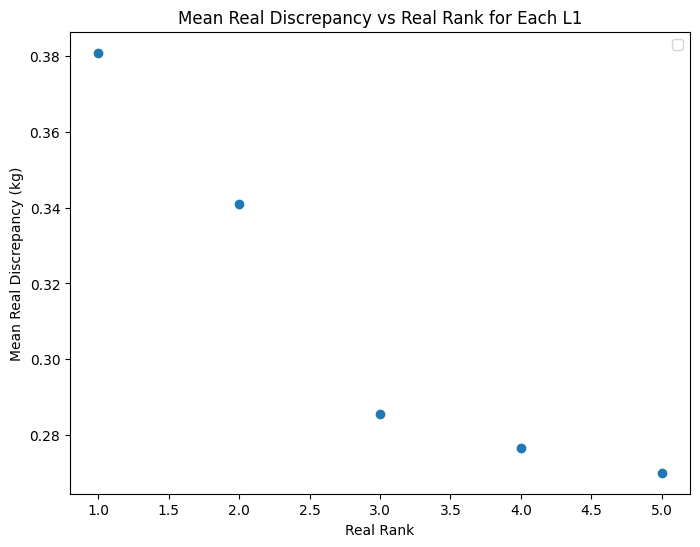

In [84]:
# Scatter plot of mean real discrepancy vs real rank for each L1
plt.figure(figsize=(8, 6))
mean_discrepancies = []
for i, discrepancies in real_discrepancies.items():
    mean_discrepancies.append(np.mean(discrepancies))
plt.scatter(real_ranks, mean_discrepancies)
plt.xlabel('Real Rank')
plt.ylabel('Mean Real Discrepancy (kg)')
plt.title('Mean Real Discrepancy vs Real Rank for Each L1')
plt.legend()
plt.show()

### Generate nested measurements for different parameter combinations

/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/ecd_nested_simulation_functions/generate_ecd_dummy_data.py:1059: RuntimeWarning: divide by zero encountered in scalar divide
  percent_shift = 100 * (1 - percent_below_threshold_bunched/percent_below_threshold_original)
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/ecd_nested_simulation_functions/generate_ecd_dummy_data.py:1059: RuntimeWarning: divide by zero encountered in scalar divide
  percent_shift = 100 * (1 - percent_below_threshold_bunched/percent_below_threshold_original)
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/ecd_nested_simulation_functions/generate_ecd_dummy_data.py:1059: RuntimeWarning: divide by zero encountered in scalar divide
  percent_shift = 100 * (1 - percent_below_threshold_bunched/percent_below_threshold_original)
/Users/amritasingh/Documents/CEGIS/discsim/api/utils/Pre Survey Nested Simulation/ecd_nested_s

NameError: name 'n_L1_units_rewarded' is not defined

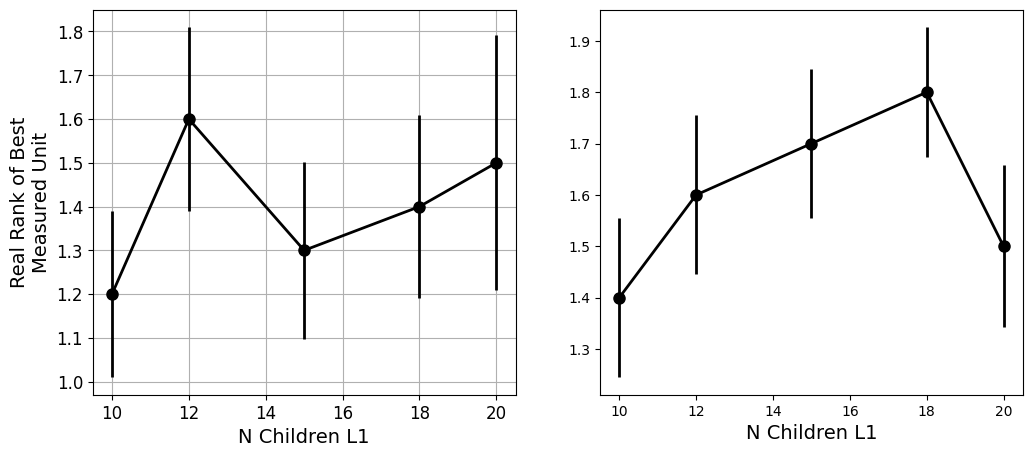

In [ ]:
n_L0s_per_L1 = [10]
n_children_per_L0 = [20]
n_children_per_L1 = [10, 12, 15, 18, 20]
n_L1_units_rewarded = 2


results_df = ecd_sampling_strategy.L0_unit_classification_confidence(
    real_params=real_params,
    n_L1s=5,
    n_L0s_per_L1=n_L0s_per_L1,  # List of values to test
    n_children_per_L0=n_children_per_L0,
    n_children_L1=n_children_per_L1,      # List of values to test
    n_children_L2 = 5,
    haz_params=haz_params,
    waz_params=waz_params,
    whz_params_lying=whz_params_lying,
    whz_params_standing=whz_params_standing,
    measurement_var='weight',
    measurement_unit='kg',
    n_L1_units_rewarded=n_L1_units_rewarded,
    real_percent_stunting=36,
    real_percent_underweight=34.2,
    mean_collusion_index=0.2,
    random_seed=42,
    n_simulations=10
)

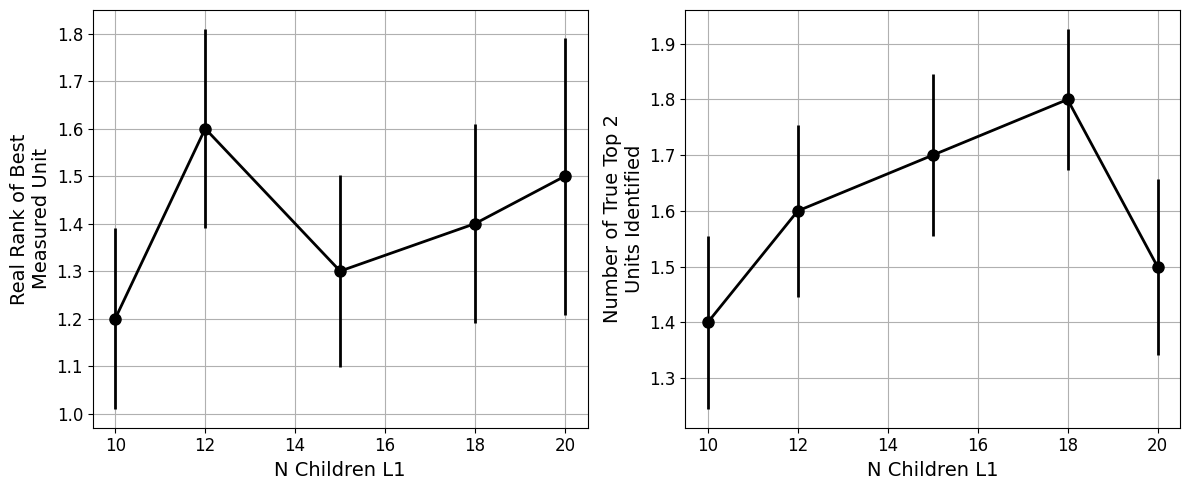

In [ ]:
figs = ecd_sampling_strategy.plot_L0_unit_classification_confidence_vs_parameters(n_L0s_per_L1,
    n_children_per_L0,
    n_children_per_L1,
    results_df,
    n_L1_units_rewarded)
# Display plots
for fig in figs:
    plt.figure(fig.number)
    plt.show()

In [29]:
results_df

,n_L0s_per_L1,n_children_per_L0,n_children_L1,real_rank_mean,real_rank_sem,n_overlap_mean,n_overlap_sem
0,10,20,10,1.8,0.236643,1.4,0.154919
1,10,20,12,1.8,0.340588,1.4,0.154919
2,10,20,15,1.3,0.202485,1.7,0.144914
3,10,20,18,1.4,0.209762,1.7,0.144914
4,10,20,20,1.1,0.094868,1.9,0.094868
